In [41]:
# 统一论文图的风格和尺寸, 方便后续拼接
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm   # 修改 1：新增，用于手动加载 Arial.ttf


# =========================
# 修改 2：只需要改这里
# =========================
ARIAL_TTF_PATH = "/data/jychen/package/Arial/arial.ttf"   # 改成你的 arial.ttf 实际路径
USE_ARIAL_TTF = True                # True = 从 ttf 文件加载 Arial；False = 直接用系统字体名


_PUB_FONT_NAME = None


def load_pub_font():
    """
    手动加载 Arial.ttf，并返回字体在 matplotlib 中识别到的真实名称。
    这样可以避免系统装了 Arial 但 matplotlib 仍然找不到的问题。
    """
    global _PUB_FONT_NAME

    if _PUB_FONT_NAME is not None:
        return _PUB_FONT_NAME

    if USE_ARIAL_TTF:
        if not os.path.exists(ARIAL_TTF_PATH):
            raise FileNotFoundError(f"找不到 Arial 字体文件: {ARIAL_TTF_PATH}")

        fm.fontManager.addfont(ARIAL_TTF_PATH)
        _PUB_FONT_NAME = fm.FontProperties(fname=ARIAL_TTF_PATH).get_name()
    else:
        _PUB_FONT_NAME = "Arial"

    print(f"Using font: {_PUB_FONT_NAME}")
    return _PUB_FONT_NAME


def mm_to_inch(mm):
    return mm / 25.4


FIG_SIZE = {
    "single": 100,
    "double": 200,
}


FIG_PRESETS = {
    "single_small":  ("single", 60),
    "single_medium": ("single", 75),
    "double_short":  ("double", 70),
    "double_medium": ("double", 100),
    "double_large":  ("double", 140),
}


_SHARED_FONT_SIZES = {
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
}


def set_pub_style():
    pub_font = load_pub_font()   # 修改 3：每次设置风格前，先确保 Arial.ttf 已经加载

    base = {
        # 修改 4：不再直接写死 "Arial"，而是使用 ttf 文件真实识别到的字体名
        "font.family": pub_font,
        "font.sans-serif": [pub_font, "Arial", "Helvetica", "Liberation Sans", "DejaVu Sans"],

        "font.weight": "normal",
        "axes.labelweight": "normal",
        "axes.titleweight": "normal",

        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",

        # 让 $...$ 数学文本也尽量使用同一套 Arial 字体，避免最后几张图混入 DejaVu。
        "mathtext.fontset": "custom",
        "mathtext.rm": pub_font,
        "mathtext.it": pub_font,
        "mathtext.bf": pub_font,
        "mathtext.default": "regular",

        # 稍粗一些的论文图风格
        "axes.linewidth": 1.5,
        "xtick.major.width": 1.4,
        "ytick.major.width": 1.4,
        "xtick.minor.width": 1.1,
        "ytick.minor.width": 1.1,
        "xtick.major.size": 4.5,
        "ytick.major.size": 4.5,
        "xtick.minor.size": 2.8,
        "ytick.minor.size": 2.8,
        "xtick.direction": "in",
        "ytick.direction": "in",

        "lines.linewidth": 1.7,
        "patch.linewidth": 1.3,

        "legend.frameon": False,
        "legend.handlelength": 1.5,
        "legend.handletextpad": 0.4,

        "axes.unicode_minus": False,
        "axes.spines.top": True,
        "axes.spines.right": True,

        "savefig.dpi": 600,
        "figure.dpi": 120,
    }

    base.update(_SHARED_FONT_SIZES)
    mpl.rcParams.update(base)


def new_figure(mode="single", height_mm=65):
    set_pub_style()
    width_mm = FIG_SIZE[mode]
    fig, ax = plt.subplots(
        figsize=(mm_to_inch(width_mm), mm_to_inch(height_mm))
    )
    return fig, ax


def new_subplots(nrows, ncols, preset="double_medium", **kwargs):
    set_pub_style()
    mode, height_mm = FIG_PRESETS[preset]
    width_mm = FIG_SIZE[mode]

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(mm_to_inch(width_mm), mm_to_inch(height_mm)),
        **kwargs
    )
    return fig, axes


def savefig_pub(fig, filename, dpi=600, tight=False):
    if tight:
        fig.savefig(filename, dpi=dpi, bbox_inches="tight", pad_inches=0.02)
    else:
        fig.savefig(filename, dpi=dpi)


# 应用统一风格模板
set_pub_style()

Using font: Arial


Traj 3/3: 100%|██████████| 10001/10001 [00:13<00:00, 726.61it/s]


findfont: Font family ['cursive'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, Comic Neue, Comic Sans MS, cursive


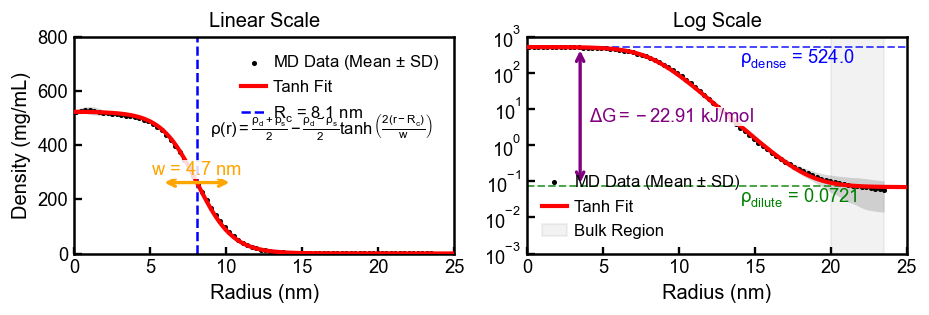

In [42]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import sys
from tqdm import tqdm
import warnings

# 忽略不必要的警告
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

# ===================== 用户设置 =====================
# IDP_SOLV
topology = "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_0/TR_Mdvwhole/pbc.tpr"
trajectory_files = ["/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_0/TR_Mdvwhole/clus_centered.xtc",
                    "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_0_re1/TR_Mdvwhole/clus_centered.xtc",
                    "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_0_re2/TR_Mdvwhole/clus_centered.xtc"
]
selection = "protein"
n_bins = 80               
start_pct = 0.5         
MIN_FIT_COVERAGE = 1.0  # 只拟合所有已分析帧内都有效的 radial bins

TEMP = 310                
GAS_CONST = 0.008314      
CONVERSION_FACTOR = 1660.54 

# --- Plot configuration（局部补充；字体与风格以 cell1 为准） ---
# 两子图使用 "double_short" 预设（如需调整，修改下面两行）
SUBPLOT_PRESET = "double_short"
MD_POINT_SIZE = 3
TEXT_FONTSIZE = float(plt.rcParams["font.size"])  # 跟随 cell1 的统一字号（当前为 9）
FORMULA_FONTSIZE = TEXT_FONTSIZE - 1               # 拟合公式比普通标注再小 1 号
PHASE_LABEL_Y_SCALE = 0.35                         # dense / dilute 文本统一放在对应虚线下方
FORMULA_X, FORMULA_Y = 0.65, 0.58                  # 拟合公式移到中间空白处
DELTAG_X_OFFSET = 0.6                              # ΔG 文本放在箭头右侧一点
DELTAG_ZORDER = 20                                # ΔG 文本始终压在最上层
ANNOTATION_BBOX = dict(facecolor='white', alpha=0.85, edgecolor='none', pad=0.2)  # 与 ΔG 标注保持一致

# ===================== 数据计算 =====================
u_init = mda.Universe(topology, trajectory_files[0])
r_max_auto = np.min(u_init.dimensions[:3]) / 2.0
bins = np.linspace(0, r_max_auto, n_bins + 1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
volumes = 4/3 * np.pi * (bins[1:]**3 - bins[:-1]**3)

all_profiles = []
fit_valid_masks = []
num_trajs = len(trajectory_files)

for i, traj in enumerate(trajectory_files):
    u = mda.Universe(topology, traj)
    sel = u.select_atoms(selection)
    mass_arr = sel.masses  
    
    t_mass = np.zeros(n_bins)
    b_count = np.zeros(n_bins)
    
    n_frames = len(u.trajectory)
    start_frame = int(n_frames * start_pct)
    
    desc_str = f"Traj {i+1}/{num_trajs}"
    
    for ts in tqdm(u.trajectory[start_frame:], desc=desc_str, file=sys.stdout):
        safe_r = np.min(ts.dimensions[:3]) / 2.0
        dists = np.linalg.norm(sel.positions, axis=1)
        m_counts, _ = np.histogram(dists, bins=bins, weights=mass_arr)
        
        mask = bins[1:] <= safe_r
        t_mass[mask] += m_counts[mask]
        b_count[mask] += 1
    
    v = b_count > 0
    dens = np.zeros(n_bins)
    dens[v] = (t_mass[v] / b_count[v] / volumes[v]) * CONVERSION_FACTOR
    dens[~v] = np.nan
    used_frame_count = max(n_frames - start_frame, 0)
    coverage = np.divide(
        b_count,
        used_frame_count,
        out=np.zeros_like(b_count, dtype=float),
        where=used_frame_count > 0,
    )
    fit_valid_masks.append(v & (coverage >= MIN_FIT_COVERAGE))
    all_profiles.append(dens)
    u.trajectory.close() 

# ===================== 统计与拟合 =====================
all_profiles = np.array(all_profiles)
fit_valid_masks = np.array(fit_valid_masks, dtype=bool)
common_fit_mask = np.all(fit_valid_masks, axis=0) if fit_valid_masks.size else np.zeros(n_bins, dtype=bool)
mean_rho = np.nanmean(all_profiles, axis=0)
std_rho = np.nanstd(all_profiles, axis=0)

r_nm = bin_centers / 10.0
eps = 1e-8
v_mask = (mean_rho > eps) & (~np.isnan(mean_rho)) & common_fit_mask
r_fit = r_nm[v_mask]
rho_fit = mean_rho[v_mask]
fit_valid_radius_nm = float(np.nanmax(r_nm[v_mask])) if np.any(v_mask) else np.nan

def tanh_func(r, rho_d, rho_s, Rc, w):
    return (rho_d + rho_s) / 2 - ((rho_d - rho_s) / 2) * np.tanh(2 * (r - Rc) / w)

def log_tanh(r, rho_d, rho_s, Rc, w):
    return np.log(np.maximum(tanh_func(r, rho_d, rho_s, Rc, w), eps))

try:
    p0 = [np.max(rho_fit), np.min(rho_fit), np.median(r_fit), 3.0]
    popt, _ = curve_fit(log_tanh, r_fit, np.log(rho_fit), p0=p0, bounds=(1e-10, [2500, 500, r_fit[-1], 20]))
    rho_d_f, rho_s_f, Rc_f, w_f = popt
    rho_s_avg = rho_s_f
    deltaG = -GAS_CONST * TEMP * np.log(rho_d_f / rho_s_f)
except:
    popt = None; deltaG = np.nan

# ===================== 绘图 =====================
# 使用 cell1 中定义的 new_subplots，预设由上面的 SUBPLOT_PRESET 控制
fig, (ax1, ax2) = new_subplots(1, 2, preset=SUBPLOT_PRESET)
x_max = 25.0

for ax in [ax1, ax2]:
    if len(trajectory_files) > 1:
        lower = np.maximum(mean_rho - std_rho, 1e-7) if ax == ax2 else mean_rho - std_rho
        ax.fill_between(r_nm, lower, mean_rho + std_rho, color='gray', alpha=0.3, lw=0, zorder=1)
    ax.scatter(r_nm, mean_rho, color='black', s=MD_POINT_SIZE, label=r'MD Data (Mean $\pm$ SD)', zorder=2)
    
    if np.isfinite(fit_valid_radius_nm) and fit_valid_radius_nm < x_max:
        ax.axvspan(fit_valid_radius_nm, x_max, color='0.85', alpha=0.35, lw=0, label='outside valid radius', zorder=0)
        ax.axvline(fit_valid_radius_nm, color='0.45', ls=':', lw=1.0, alpha=0.8, zorder=4)
    
    if popt is not None:
        curve_x_max = min(x_max, fit_valid_radius_nm) if np.isfinite(fit_valid_radius_nm) and fit_valid_radius_nm > 0 else x_max
        r_smooth = np.linspace(0, curve_x_max, 500)
        ax.plot(r_smooth, tanh_func(r_smooth, *popt), color='red', lw=2.5, label='Density curve', zorder=5)
    ax.set_xlim(0, x_max)
    ax.set_xlabel("Radius (nm)")
    if ax == ax1:
        ax.set_ylabel("Density (mg/mL)")

# --- ax1: Linear ---
ax1.set_ylim(0, 800)
ax1.set_title("Linear Scale")
if popt is not None:
    # 绘制 Rc 垂直线
    ax1.axvline(Rc_f, color='blue', ls='--', lw=1.5, label=fr'$R_c$ = {Rc_f:.1f} nm')
    
    # 【新增：绘制 w 标注】
    # 计算密度下降的中点高度
    y_mid = (rho_d_f + rho_s_avg) / 2
    # 绘制水平双向箭头表示 w
    w_arrow = ax1.annotate('', xy=(Rc_f - w_f/2, y_mid), xytext=(Rc_f + w_f/2, y_mid),
                           arrowprops=dict(arrowstyle='<->', color='orange', lw=2), zorder=DELTAG_ZORDER)
    if w_arrow.arrow_patch is not None:
        w_arrow.arrow_patch.set_zorder(DELTAG_ZORDER)
    # 在箭头上方标注数值
    ax1.text(Rc_f, y_mid + 30, fr'$w$ = {w_f:.1f} nm', color='orange', fontweight='bold',
             ha='center', fontsize=TEXT_FONTSIZE, zorder=DELTAG_ZORDER, bbox=ANNOTATION_BBOX)

    # 公式展示
    formula = r"$\rho(r) = \frac{\rho_d + \rho_s}{2} - \frac{\rho_d - \rho_s}{2} \tanh\left(\frac{2(r-R_c)}{w}\right)$"
    ax1.text(FORMULA_X, FORMULA_Y, formula, transform=ax1.transAxes, fontsize=FORMULA_FONTSIZE,
             ha='center', va='center', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

ax1.legend(loc='upper right')

# --- ax2: Log ---
ax2.set_yscale('log')
ax2.set_ylim(1e-3, 1e3)
ax2.yaxis.set_minor_locator(mpl.ticker.NullLocator())
ax2.set_title("Log Scale")
if popt is not None:
    ax2.axhline(rho_d_f, color='blue', ls='--', lw=1.2, alpha=0.7)
    ax2.text(14, rho_d_f*PHASE_LABEL_Y_SCALE, fr"$\rho_{{dense}}$ = {rho_d_f:.1f}", color='blue', fontweight='bold', fontsize=TEXT_FONTSIZE)
    
    ax2.axhline(rho_s_avg, color='green', ls='--', lw=1.2, alpha=0.7)
    ax2.text(14, rho_s_avg*PHASE_LABEL_Y_SCALE, fr"$\rho_{{dilute}}$ = {rho_s_avg:.4f}", color='green', fontweight='bold', fontsize=TEXT_FONTSIZE)
    
    arrow_x = 3.5
    ax2.annotate('', xy=(arrow_x, rho_s_avg), xytext=(arrow_x, rho_d_f),
                 arrowprops=dict(arrowstyle='<->', color='purple', lw=2))
    ax2.text(arrow_x + DELTAG_X_OFFSET, np.sqrt(rho_d_f * rho_s_avg),
             fr"$\Delta G_{{\mathrm{{app}}}} = {deltaG:.2f}$ kJ/mol", color='purple', fontweight='bold',
             ha='left', va='center', fontsize=TEXT_FONTSIZE, zorder=DELTAG_ZORDER,
             bbox=ANNOTATION_BBOX)
    

ax2.legend(loc='lower left')

plt.tight_layout()
plt.show()

Traj 3/3: 100%|██████████| 10001/10001 [00:13<00:00, 721.09it/s]


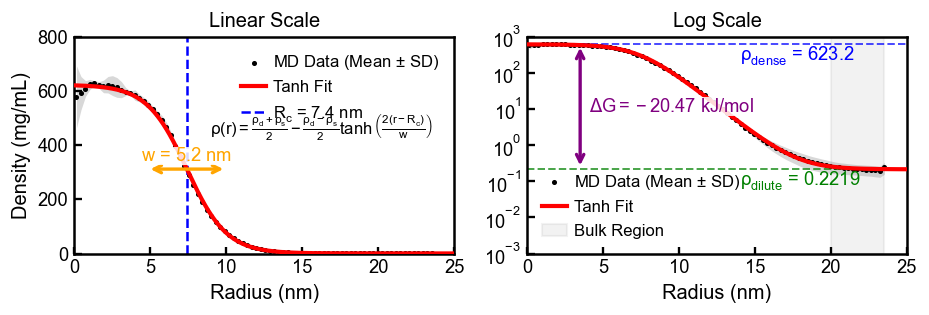

In [43]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import sys
from tqdm import tqdm
import warnings

# 忽略不必要的警告
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

# ===================== 用户设置 =====================
# Helix_SOLV
topology = "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_700/TR_Mdvwhole/pbc.tpr"  # 拓扑文件

trajectory_files = ["/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_700/TR_Mdvwhole/clus_centered.xtc",
                    "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_700_re1/TR_Mdvwhole/clus_centered.xtc",
                    "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_700_re2/TR_Mdvwhole/clus_centered.xtc"
]
selection = "protein"
n_bins = 80               
start_pct = 0.5        
MIN_FIT_COVERAGE = 1.0  # 只拟合所有已分析帧内都有效的 radial bins

TEMP = 310                
GAS_CONST = 0.008314      
CONVERSION_FACTOR = 1660.54 

# --- Plot configuration（局部补充；字体与风格以 cell1 为准） ---
# 两子图使用 "double_short" 预设（如需调整，修改下面两行）
SUBPLOT_PRESET = "double_short"
MD_POINT_SIZE = 3
TEXT_FONTSIZE = float(plt.rcParams["font.size"])  # 跟随 cell1 的统一字号（当前为 9）
FORMULA_FONTSIZE = TEXT_FONTSIZE - 1               # 拟合公式比普通标注再小 1 号
PHASE_LABEL_Y_SCALE = 0.35                          # dense / dilute 文本统一放在对应虚线下方
FORMULA_X, FORMULA_Y = 0.65, 0.58                  # 拟合公式移到中间空白处
DELTAG_X_OFFSET = 0.6                              # ΔG 文本放在箭头右侧一点
DELTAG_ZORDER = 20                                # ΔG 文本始终压在最上层
ANNOTATION_BBOX = dict(facecolor='white', alpha=0.85, edgecolor='none', pad=0.2)  # 与 ΔG 标注保持一致

# ===================== 数据计算 =====================
u_init = mda.Universe(topology, trajectory_files[0])
r_max_auto = np.min(u_init.dimensions[:3]) / 2.0
bins = np.linspace(0, r_max_auto, n_bins + 1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
volumes = 4/3 * np.pi * (bins[1:]**3 - bins[:-1]**3)

all_profiles = []
fit_valid_masks = []
num_trajs = len(trajectory_files)

for i, traj in enumerate(trajectory_files):
    u = mda.Universe(topology, traj)
    sel = u.select_atoms(selection)
    mass_arr = sel.masses  
    
    t_mass = np.zeros(n_bins)
    b_count = np.zeros(n_bins)
    
    n_frames = len(u.trajectory)
    start_frame = int(n_frames * start_pct)
    
    desc_str = f"Traj {i+1}/{num_trajs}"
    
    for ts in tqdm(u.trajectory[start_frame:], desc=desc_str, file=sys.stdout):
        safe_r = np.min(ts.dimensions[:3]) / 2.0
        dists = np.linalg.norm(sel.positions, axis=1)
        m_counts, _ = np.histogram(dists, bins=bins, weights=mass_arr)
        
        mask = bins[1:] <= safe_r
        t_mass[mask] += m_counts[mask]
        b_count[mask] += 1
    
    v = b_count > 0
    dens = np.zeros(n_bins)
    dens[v] = (t_mass[v] / b_count[v] / volumes[v]) * CONVERSION_FACTOR
    dens[~v] = np.nan
    used_frame_count = max(n_frames - start_frame, 0)
    coverage = np.divide(
        b_count,
        used_frame_count,
        out=np.zeros_like(b_count, dtype=float),
        where=used_frame_count > 0,
    )
    fit_valid_masks.append(v & (coverage >= MIN_FIT_COVERAGE))
    all_profiles.append(dens)
    u.trajectory.close() 

# ===================== 统计与拟合 =====================
all_profiles = np.array(all_profiles)
fit_valid_masks = np.array(fit_valid_masks, dtype=bool)
common_fit_mask = np.all(fit_valid_masks, axis=0) if fit_valid_masks.size else np.zeros(n_bins, dtype=bool)
mean_rho = np.nanmean(all_profiles, axis=0)
std_rho = np.nanstd(all_profiles, axis=0)

r_nm = bin_centers / 10.0
eps = 1e-8
v_mask = (mean_rho > eps) & (~np.isnan(mean_rho)) & common_fit_mask
r_fit = r_nm[v_mask]
rho_fit = mean_rho[v_mask]
fit_valid_radius_nm = float(np.nanmax(r_nm[v_mask])) if np.any(v_mask) else np.nan

def tanh_func(r, rho_d, rho_s, Rc, w):
    return (rho_d + rho_s) / 2 - ((rho_d - rho_s) / 2) * np.tanh(2 * (r - Rc) / w)

def log_tanh(r, rho_d, rho_s, Rc, w):
    return np.log(np.maximum(tanh_func(r, rho_d, rho_s, Rc, w), eps))

try:
    p0 = [np.max(rho_fit), np.min(rho_fit), np.median(r_fit), 3.0]
    popt, _ = curve_fit(log_tanh, r_fit, np.log(rho_fit), p0=p0, bounds=(1e-10, [2500, 500, r_fit[-1], 20]))
    rho_d_f, rho_s_f, Rc_f, w_f = popt
    rho_s_avg = rho_s_f
    deltaG = -GAS_CONST * TEMP * np.log(rho_d_f / rho_s_f)
except:
    popt = None; deltaG = np.nan

# ===================== 绘图 =====================
# 使用 cell1 中定义的 new_subplots，预设由上面的 SUBPLOT_PRESET 控制
fig, (ax1, ax2) = new_subplots(1, 2, preset=SUBPLOT_PRESET)
x_max = 25.0

for ax in [ax1, ax2]:
    if len(trajectory_files) > 1:
        lower = np.maximum(mean_rho - std_rho, 1e-7) if ax == ax2 else mean_rho - std_rho
        ax.fill_between(r_nm, lower, mean_rho + std_rho, color='gray', alpha=0.3, lw=0, zorder=1)
    ax.scatter(r_nm, mean_rho, color='black', s=MD_POINT_SIZE, label=r'MD Data (Mean $\pm$ SD)', zorder=2)
    
    if np.isfinite(fit_valid_radius_nm) and fit_valid_radius_nm < x_max:
        ax.axvspan(fit_valid_radius_nm, x_max, color='0.85', alpha=0.35, lw=0, label='outside valid radius', zorder=0)
        ax.axvline(fit_valid_radius_nm, color='0.45', ls=':', lw=1.0, alpha=0.8, zorder=4)
    
    if popt is not None:
        curve_x_max = min(x_max, fit_valid_radius_nm) if np.isfinite(fit_valid_radius_nm) and fit_valid_radius_nm > 0 else x_max
        r_smooth = np.linspace(0, curve_x_max, 500)
        ax.plot(r_smooth, tanh_func(r_smooth, *popt), color='red', lw=2.5, label='Density curve', zorder=5)
    ax.set_xlim(0, x_max)
    ax.set_xlabel("Radius (nm)")
    if ax == ax1:
        ax.set_ylabel("Density (mg/mL)")

# --- ax1: Linear ---
ax1.set_ylim(0, 800)
ax1.set_title("Linear Scale")
if popt is not None:
    # 绘制 Rc 垂直线
    ax1.axvline(Rc_f, color='blue', ls='--', lw=1.5, label=fr'$R_c$ = {Rc_f:.1f} nm')
    
    # 【新增：绘制 w 标注】
    # 计算密度下降的中点高度
    y_mid = (rho_d_f + rho_s_avg) / 2
    # 绘制水平双向箭头表示 w
    w_arrow = ax1.annotate('', xy=(Rc_f - w_f/2, y_mid), xytext=(Rc_f + w_f/2, y_mid),
                           arrowprops=dict(arrowstyle='<->', color='orange', lw=2), zorder=DELTAG_ZORDER)
    if w_arrow.arrow_patch is not None:
        w_arrow.arrow_patch.set_zorder(DELTAG_ZORDER)
    # 在箭头上方标注数值
    ax1.text(Rc_f, y_mid + 30, fr'$w$ = {w_f:.1f} nm', color='orange', fontweight='bold',
             ha='center', fontsize=TEXT_FONTSIZE, zorder=DELTAG_ZORDER, bbox=ANNOTATION_BBOX)

    # 公式展示
    formula = r"$\rho(r) = \frac{\rho_d + \rho_s}{2} - \frac{\rho_d - \rho_s}{2} \tanh\left(\frac{2(r-R_c)}{w}\right)$"
    ax1.text(FORMULA_X, FORMULA_Y, formula, transform=ax1.transAxes, fontsize=FORMULA_FONTSIZE,
             ha='center', va='center', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

ax1.legend(loc='upper right')

# --- ax2: Log ---
ax2.set_yscale('log')
ax2.set_ylim(1e-3, 1e3)
ax2.yaxis.set_minor_locator(mpl.ticker.NullLocator())
ax2.set_title("Log Scale")
if popt is not None:
    ax2.axhline(rho_d_f, color='blue', ls='--', lw=1.2, alpha=0.7)
    ax2.text(14, rho_d_f*PHASE_LABEL_Y_SCALE, fr"$\rho_{{dense}}$ = {rho_d_f:.1f}", color='blue', fontweight='bold', fontsize=TEXT_FONTSIZE)
    
    ax2.axhline(rho_s_avg, color='green', ls='--', lw=1.2, alpha=0.7)
    ax2.text(14, rho_s_avg*PHASE_LABEL_Y_SCALE, fr"$\rho_{{dilute}}$ = {rho_s_avg:.4f}", color='green', fontweight='bold', fontsize=TEXT_FONTSIZE)
    
    arrow_x = 3.5
    ax2.annotate('', xy=(arrow_x, rho_s_avg), xytext=(arrow_x, rho_d_f),
                 arrowprops=dict(arrowstyle='<->', color='purple', lw=2))
    ax2.text(arrow_x + DELTAG_X_OFFSET, np.sqrt(rho_d_f * rho_s_avg),
             fr"$\Delta G_{{\mathrm{{app}}}} = {deltaG:.2f}$ kJ/mol", color='purple', fontweight='bold',
             ha='left', va='center', fontsize=TEXT_FONTSIZE, zorder=DELTAG_ZORDER,
             bbox=ANNOTATION_BBOX)
    

ax2.legend(loc='lower left')

plt.tight_layout()
plt.show()

Traj 1/3:   0%|          | 0/10001 [00:00<?, ?it/s]

Traj 3/3: 100%|██████████| 10001/10001 [00:17<00:00, 581.26it/s]


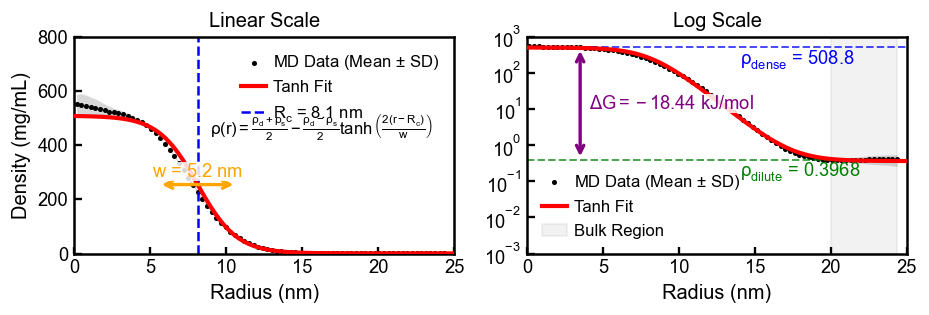

In [44]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import sys
from tqdm import tqdm
import warnings

# 忽略不必要的警告
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

# ===================== 用户设置 =====================
topology = "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Onmem/muti_chain/POPC7-POPG3/alhx_0_plus1/TR_Mdvwhole/pbc.tpr"
trajectory_files = ["/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Onmem/muti_chain/POPC7-POPG3/alhx_0_plus1/TR_Mdvwhole/clus_centered.xtc",
                    "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Onmem/muti_chain/POPC7-POPG3/alhx_0_plus2/TR_Mdvwhole/clus_centered.xtc",
                    "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Onmem/muti_chain/POPC7-POPG3/alhx_0_plus3/TR_Mdvwhole/clus_centered.xtc"
]
selection = "protein"
n_bins = 80               
start_pct = 0           
MIN_FIT_COVERAGE = 1.0  # 只拟合所有已分析帧内都有效的 radial bins

TEMP = 310                
GAS_CONST = 0.008314      
CONVERSION_FACTOR = 1660.54 

# --- Plot configuration（局部补充；字体与风格以 cell1 为准） ---
# 两子图使用 "double_short" 预设（如需调整，修改下面两行）
SUBPLOT_PRESET = "double_short"
MD_POINT_SIZE = 3
TEXT_FONTSIZE = float(plt.rcParams["font.size"])  # 跟随 cell1 的统一字号（当前为 9）
FORMULA_FONTSIZE = TEXT_FONTSIZE - 1               # 拟合公式比普通标注再小 1 号
PHASE_LABEL_Y_SCALE = 0.35                         # dense / dilute 文本统一放在对应虚线下方
FORMULA_X, FORMULA_Y = 0.65, 0.58                  # 拟合公式移到中间空白处
DELTAG_X_OFFSET = 0.6                              # ΔG 文本放在箭头右侧一点
DELTAG_ZORDER = 20                                # ΔG 文本始终压在最上层
ANNOTATION_BBOX = dict(facecolor='white', alpha=0.85, edgecolor='none', pad=0.2)  # 与 ΔG 标注保持一致

# ===================== 数据计算 =====================
u_init = mda.Universe(topology, trajectory_files[0])
r_max_auto = np.min(u_init.dimensions[:3]) / 2.0
bins = np.linspace(0, r_max_auto, n_bins + 1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
volumes = 4/3 * np.pi * (bins[1:]**3 - bins[:-1]**3)

all_profiles = []
fit_valid_masks = []
num_trajs = len(trajectory_files)

for i, traj in enumerate(trajectory_files):
    u = mda.Universe(topology, traj)
    sel = u.select_atoms(selection)
    mass_arr = sel.masses  
    
    t_mass = np.zeros(n_bins)
    b_count = np.zeros(n_bins)
    
    n_frames = len(u.trajectory)
    start_frame = int(n_frames * start_pct)
    
    desc_str = f"Traj {i+1}/{num_trajs}"
    
    for ts in tqdm(u.trajectory[start_frame:], desc=desc_str, file=sys.stdout):
        safe_r = np.min(ts.dimensions[:3]) / 2.0
        dists = np.linalg.norm(sel.positions, axis=1)
        m_counts, _ = np.histogram(dists, bins=bins, weights=mass_arr)
        
        mask = bins[1:] <= safe_r
        t_mass[mask] += m_counts[mask]
        b_count[mask] += 1
    
    v = b_count > 0
    dens = np.zeros(n_bins)
    dens[v] = (t_mass[v] / b_count[v] / volumes[v]) * CONVERSION_FACTOR
    dens[~v] = np.nan
    used_frame_count = max(n_frames - start_frame, 0)
    coverage = np.divide(
        b_count,
        used_frame_count,
        out=np.zeros_like(b_count, dtype=float),
        where=used_frame_count > 0,
    )
    fit_valid_masks.append(v & (coverage >= MIN_FIT_COVERAGE))
    all_profiles.append(dens)
    u.trajectory.close() 

# ===================== 统计与拟合 =====================
all_profiles = np.array(all_profiles)
fit_valid_masks = np.array(fit_valid_masks, dtype=bool)
common_fit_mask = np.all(fit_valid_masks, axis=0) if fit_valid_masks.size else np.zeros(n_bins, dtype=bool)
mean_rho = np.nanmean(all_profiles, axis=0)
std_rho = np.nanstd(all_profiles, axis=0)

r_nm = bin_centers / 10.0
eps = 1e-8
v_mask = (mean_rho > eps) & (~np.isnan(mean_rho)) & common_fit_mask
r_fit = r_nm[v_mask]
rho_fit = mean_rho[v_mask]
fit_valid_radius_nm = float(np.nanmax(r_nm[v_mask])) if np.any(v_mask) else np.nan

def tanh_func(r, rho_d, rho_s, Rc, w):
    return (rho_d + rho_s) / 2 - ((rho_d - rho_s) / 2) * np.tanh(2 * (r - Rc) / w)

def log_tanh(r, rho_d, rho_s, Rc, w):
    return np.log(np.maximum(tanh_func(r, rho_d, rho_s, Rc, w), eps))

try:
    p0 = [np.max(rho_fit), np.min(rho_fit), np.median(r_fit), 3.0]
    popt, _ = curve_fit(log_tanh, r_fit, np.log(rho_fit), p0=p0, bounds=(1e-10, [2500, 500, r_fit[-1], 20]))
    rho_d_f, rho_s_f, Rc_f, w_f = popt
    rho_s_avg = rho_s_f
    deltaG = -GAS_CONST * TEMP * np.log(rho_d_f / rho_s_f)
except:
    popt = None; deltaG = np.nan

# ===================== 绘图 =====================
# 使用 cell1 中定义的 new_subplots，预设由上面的 SUBPLOT_PRESET 控制
fig, (ax1, ax2) = new_subplots(1, 2, preset=SUBPLOT_PRESET)
x_max = 25.0

for ax in [ax1, ax2]:
    if len(trajectory_files) > 1:
        lower = np.maximum(mean_rho - std_rho, 1e-7) if ax == ax2 else mean_rho - std_rho
        ax.fill_between(r_nm, lower, mean_rho + std_rho, color='gray', alpha=0.3, lw=0, zorder=1)
    ax.scatter(r_nm, mean_rho, color='black', s=MD_POINT_SIZE, label=r'MD Data (Mean $\pm$ SD)', zorder=2)
    
    if np.isfinite(fit_valid_radius_nm) and fit_valid_radius_nm < x_max:
        ax.axvspan(fit_valid_radius_nm, x_max, color='0.85', alpha=0.35, lw=0, label='outside valid radius', zorder=0)
        ax.axvline(fit_valid_radius_nm, color='0.45', ls=':', lw=1.0, alpha=0.8, zorder=4)
    
    if popt is not None:
        curve_x_max = min(x_max, fit_valid_radius_nm) if np.isfinite(fit_valid_radius_nm) and fit_valid_radius_nm > 0 else x_max
        r_smooth = np.linspace(0, curve_x_max, 500)
        ax.plot(r_smooth, tanh_func(r_smooth, *popt), color='red', lw=2.5, label='Density curve', zorder=5)
    ax.set_xlim(0, x_max)
    ax.set_xlabel("Radius (nm)")
    if ax == ax1:
        ax.set_ylabel("Density (mg/mL)")

# --- ax1: Linear ---
ax1.set_ylim(0, 800)
ax1.set_title("Linear Scale")
if popt is not None:
    # 绘制 Rc 垂直线
    ax1.axvline(Rc_f, color='blue', ls='--', lw=1.5, label=fr'$R_c$ = {Rc_f:.1f} nm')
    
    # 【新增：绘制 w 标注】
    # 计算密度下降的中点高度
    y_mid = (rho_d_f + rho_s_avg) / 2
    # 绘制水平双向箭头表示 w
    w_arrow = ax1.annotate('', xy=(Rc_f - w_f/2, y_mid), xytext=(Rc_f + w_f/2, y_mid),
                           arrowprops=dict(arrowstyle='<->', color='orange', lw=2), zorder=DELTAG_ZORDER)
    if w_arrow.arrow_patch is not None:
        w_arrow.arrow_patch.set_zorder(DELTAG_ZORDER)
    # 在箭头上方标注数值
    ax1.text(Rc_f, y_mid + 30, fr'$w$ = {w_f:.1f} nm', color='orange', fontweight='bold',
             ha='center', fontsize=TEXT_FONTSIZE, zorder=DELTAG_ZORDER, bbox=ANNOTATION_BBOX)

    # 公式展示
    formula = r"$\rho(r) = \frac{\rho_d + \rho_s}{2} - \frac{\rho_d - \rho_s}{2} \tanh\left(\frac{2(r-R_c)}{w}\right)$"
    ax1.text(FORMULA_X, FORMULA_Y, formula, transform=ax1.transAxes, fontsize=FORMULA_FONTSIZE,
             ha='center', va='center', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

ax1.legend(loc='upper right')

# --- ax2: Log ---
ax2.set_yscale('log')
ax2.set_ylim(1e-3, 1e3)
ax2.yaxis.set_minor_locator(mpl.ticker.NullLocator())
ax2.set_title("Log Scale")
if popt is not None:
    ax2.axhline(rho_d_f, color='blue', ls='--', lw=1.2, alpha=0.7)
    ax2.text(14, rho_d_f*PHASE_LABEL_Y_SCALE, fr"$\rho_{{dense}}$ = {rho_d_f:.1f}", color='blue', fontweight='bold', fontsize=TEXT_FONTSIZE)
    
    ax2.axhline(rho_s_avg, color='green', ls='--', lw=1.2, alpha=0.7)
    ax2.text(14, rho_s_avg*PHASE_LABEL_Y_SCALE, fr"$\rho_{{dilute}}$ = {rho_s_avg:.4f}", color='green', fontweight='bold', fontsize=TEXT_FONTSIZE)
    
    arrow_x = 3.5
    ax2.annotate('', xy=(arrow_x, rho_s_avg), xytext=(arrow_x, rho_d_f),
                 arrowprops=dict(arrowstyle='<->', color='purple', lw=2))
    ax2.text(arrow_x + DELTAG_X_OFFSET, np.sqrt(rho_d_f * rho_s_avg),
             fr"$\Delta G_{{\mathrm{{app}}}} = {deltaG:.2f}$ kJ/mol", color='purple', fontweight='bold',
             ha='left', va='center', fontsize=TEXT_FONTSIZE, zorder=DELTAG_ZORDER,
             bbox=ANNOTATION_BBOX)
    

ax2.legend(loc='lower left')

plt.tight_layout()
plt.show()

Traj 1/3:   6%|▌         | 585/10001 [00:01<00:16, 579.26it/s]

Traj 3/3: 100%|██████████| 10001/10001 [00:17<00:00, 576.12it/s]


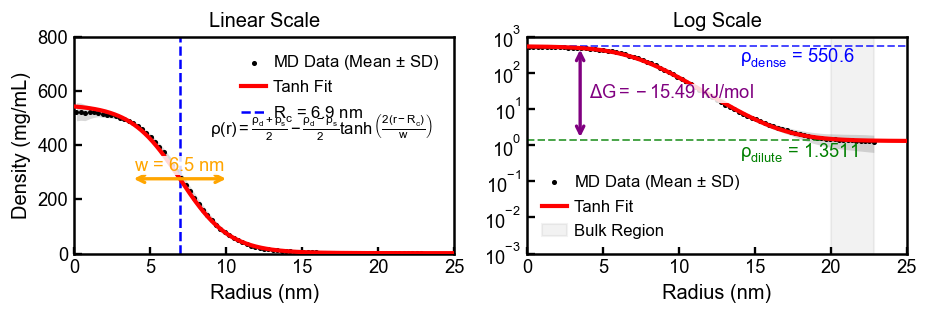

In [45]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import sys
from tqdm import tqdm
import warnings

# 忽略不必要的警告
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

# ===================== 用户设置 =====================
topology = "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Onmem/muti_chain/POPC7-POPG3/alhx_700_WALL1/TR_Mdvwhole/pbc.tpr"  # 拓扑文件

trajectory_files = ["/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Onmem/muti_chain/POPC7-POPG3/alhx_700_WALL1/TR_Mdvwhole/clus_centered.xtc",
                    "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Onmem/muti_chain/POPC7-POPG3/alhx_700_WALL2/TR_Mdvwhole/clus_centered.xtc",
                    "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Onmem/muti_chain/POPC7-POPG3/alhx_700_WALL3/TR_Mdvwhole/clus_centered.xtc"
]
selection = "protein"
n_bins = 80               
start_pct = 0.5        
MIN_FIT_COVERAGE = 1.0  # 只拟合所有已分析帧内都有效的 radial bins

TEMP = 310                
GAS_CONST = 0.008314      
CONVERSION_FACTOR = 1660.54 

# --- Plot configuration（局部补充；字体与风格以 cell1 为准） ---
# 两子图使用 "double_short" 预设（如需调整，修改下面两行）
SUBPLOT_PRESET = "double_short"
MD_POINT_SIZE = 3
TEXT_FONTSIZE = float(plt.rcParams["font.size"])  # 跟随 cell1 的统一字号（当前为 9）
FORMULA_FONTSIZE = TEXT_FONTSIZE - 1               # 拟合公式比普通标注再小 1 号
PHASE_LABEL_Y_SCALE = 0.35                          # dense / dilute 文本统一放在对应虚线下方
FORMULA_X, FORMULA_Y = 0.65, 0.58                  # 拟合公式移到中间空白处
DELTAG_X_OFFSET = 0.6                              # ΔG 文本放在箭头右侧一点
DELTAG_ZORDER = 20                                # ΔG 文本始终压在最上层
ANNOTATION_BBOX = dict(facecolor='white', alpha=0.85, edgecolor='none', pad=0.2)  # 与 ΔG 标注保持一致

# ===================== 数据计算 =====================
u_init = mda.Universe(topology, trajectory_files[0])
r_max_auto = np.min(u_init.dimensions[:3]) / 2.0
bins = np.linspace(0, r_max_auto, n_bins + 1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
volumes = 4/3 * np.pi * (bins[1:]**3 - bins[:-1]**3)

all_profiles = []
fit_valid_masks = []
num_trajs = len(trajectory_files)

for i, traj in enumerate(trajectory_files):
    u = mda.Universe(topology, traj)
    sel = u.select_atoms(selection)
    mass_arr = sel.masses  
    
    t_mass = np.zeros(n_bins)
    b_count = np.zeros(n_bins)
    
    n_frames = len(u.trajectory)
    start_frame = int(n_frames * start_pct)
    
    desc_str = f"Traj {i+1}/{num_trajs}"
    
    for ts in tqdm(u.trajectory[start_frame:], desc=desc_str, file=sys.stdout):
        safe_r = np.min(ts.dimensions[:3]) / 2.0
        dists = np.linalg.norm(sel.positions, axis=1)
        m_counts, _ = np.histogram(dists, bins=bins, weights=mass_arr)
        
        mask = bins[1:] <= safe_r
        t_mass[mask] += m_counts[mask]
        b_count[mask] += 1
    
    v = b_count > 0
    dens = np.zeros(n_bins)
    dens[v] = (t_mass[v] / b_count[v] / volumes[v]) * CONVERSION_FACTOR
    dens[~v] = np.nan
    used_frame_count = max(n_frames - start_frame, 0)
    coverage = np.divide(
        b_count,
        used_frame_count,
        out=np.zeros_like(b_count, dtype=float),
        where=used_frame_count > 0,
    )
    fit_valid_masks.append(v & (coverage >= MIN_FIT_COVERAGE))
    all_profiles.append(dens)
    u.trajectory.close() 

# ===================== 统计与拟合 =====================
all_profiles = np.array(all_profiles)
fit_valid_masks = np.array(fit_valid_masks, dtype=bool)
common_fit_mask = np.all(fit_valid_masks, axis=0) if fit_valid_masks.size else np.zeros(n_bins, dtype=bool)
mean_rho = np.nanmean(all_profiles, axis=0)
std_rho = np.nanstd(all_profiles, axis=0)

r_nm = bin_centers / 10.0
eps = 1e-8
v_mask = (mean_rho > eps) & (~np.isnan(mean_rho)) & common_fit_mask
r_fit = r_nm[v_mask]
rho_fit = mean_rho[v_mask]
fit_valid_radius_nm = float(np.nanmax(r_nm[v_mask])) if np.any(v_mask) else np.nan

def tanh_func(r, rho_d, rho_s, Rc, w):
    return (rho_d + rho_s) / 2 - ((rho_d - rho_s) / 2) * np.tanh(2 * (r - Rc) / w)

def log_tanh(r, rho_d, rho_s, Rc, w):
    return np.log(np.maximum(tanh_func(r, rho_d, rho_s, Rc, w), eps))

try:
    p0 = [np.max(rho_fit), np.min(rho_fit), np.median(r_fit), 3.0]
    popt, _ = curve_fit(log_tanh, r_fit, np.log(rho_fit), p0=p0, bounds=(1e-10, [2500, 500, r_fit[-1], 20]))
    rho_d_f, rho_s_f, Rc_f, w_f = popt
    rho_s_avg = rho_s_f
    deltaG = -GAS_CONST * TEMP * np.log(rho_d_f / rho_s_f)
except:
    popt = None; deltaG = np.nan

# ===================== 绘图 =====================
# 使用 cell1 中定义的 new_subplots，预设由上面的 SUBPLOT_PRESET 控制
fig, (ax1, ax2) = new_subplots(1, 2, preset=SUBPLOT_PRESET)
x_max = 25.0

for ax in [ax1, ax2]:
    if len(trajectory_files) > 1:
        lower = np.maximum(mean_rho - std_rho, 1e-7) if ax == ax2 else mean_rho - std_rho
        ax.fill_between(r_nm, lower, mean_rho + std_rho, color='gray', alpha=0.3, lw=0, zorder=1)
    ax.scatter(r_nm, mean_rho, color='black', s=MD_POINT_SIZE, label=r'MD Data (Mean $\pm$ SD)', zorder=2)
    
    if np.isfinite(fit_valid_radius_nm) and fit_valid_radius_nm < x_max:
        ax.axvspan(fit_valid_radius_nm, x_max, color='0.85', alpha=0.35, lw=0, label='outside valid radius', zorder=0)
        ax.axvline(fit_valid_radius_nm, color='0.45', ls=':', lw=1.0, alpha=0.8, zorder=4)
    
    if popt is not None:
        curve_x_max = min(x_max, fit_valid_radius_nm) if np.isfinite(fit_valid_radius_nm) and fit_valid_radius_nm > 0 else x_max
        r_smooth = np.linspace(0, curve_x_max, 500)
        ax.plot(r_smooth, tanh_func(r_smooth, *popt), color='red', lw=2.5, label='Density curve', zorder=5)
    ax.set_xlim(0, x_max)
    ax.set_xlabel("Radius (nm)")
    if ax == ax1:
        ax.set_ylabel("Density (mg/mL)")

# --- ax1: Linear ---
ax1.set_ylim(0, 800)
ax1.set_title("Linear Scale")
if popt is not None:
    # 绘制 Rc 垂直线
    ax1.axvline(Rc_f, color='blue', ls='--', lw=1.5, label=fr'$R_c$ = {Rc_f:.1f} nm')
    
    # 【新增：绘制 w 标注】
    # 计算密度下降的中点高度
    y_mid = (rho_d_f + rho_s_avg) / 2
    # 绘制水平双向箭头表示 w
    w_arrow = ax1.annotate('', xy=(Rc_f - w_f/2, y_mid), xytext=(Rc_f + w_f/2, y_mid),
                           arrowprops=dict(arrowstyle='<->', color='orange', lw=2), zorder=DELTAG_ZORDER)
    if w_arrow.arrow_patch is not None:
        w_arrow.arrow_patch.set_zorder(DELTAG_ZORDER)
    # 在箭头上方标注数值
    ax1.text(Rc_f, y_mid + 30, fr'$w$ = {w_f:.1f} nm', color='orange', fontweight='bold',
             ha='center', fontsize=TEXT_FONTSIZE, zorder=DELTAG_ZORDER, bbox=ANNOTATION_BBOX)

    # 公式展示
    formula = r"$\rho(r) = \frac{\rho_d + \rho_s}{2} - \frac{\rho_d - \rho_s}{2} \tanh\left(\frac{2(r-R_c)}{w}\right)$"
    ax1.text(FORMULA_X, FORMULA_Y, formula, transform=ax1.transAxes, fontsize=FORMULA_FONTSIZE,
             ha='center', va='center', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

ax1.legend(loc='upper right')

# --- ax2: Log ---
ax2.set_yscale('log')
ax2.set_ylim(1e-3, 1e3)
ax2.yaxis.set_minor_locator(mpl.ticker.NullLocator())
ax2.set_title("Log Scale")
if popt is not None:
    ax2.axhline(rho_d_f, color='blue', ls='--', lw=1.2, alpha=0.7)
    ax2.text(14, rho_d_f*PHASE_LABEL_Y_SCALE, fr"$\rho_{{dense}}$ = {rho_d_f:.1f}", color='blue', fontweight='bold', fontsize=TEXT_FONTSIZE)
    
    ax2.axhline(rho_s_avg, color='green', ls='--', lw=1.2, alpha=0.7)
    ax2.text(14, rho_s_avg*PHASE_LABEL_Y_SCALE, fr"$\rho_{{dilute}}$ = {rho_s_avg:.4f}", color='green', fontweight='bold', fontsize=TEXT_FONTSIZE)
    
    arrow_x = 3.5
    ax2.annotate('', xy=(arrow_x, rho_s_avg), xytext=(arrow_x, rho_d_f),
                 arrowprops=dict(arrowstyle='<->', color='purple', lw=2))
    ax2.text(arrow_x + DELTAG_X_OFFSET, np.sqrt(rho_d_f * rho_s_avg),
             fr"$\Delta G_{{\mathrm{{app}}}} = {deltaG:.2f}$ kJ/mol", color='purple', fontweight='bold',
             ha='left', va='center', fontsize=TEXT_FONTSIZE, zorder=DELTAG_ZORDER,
             bbox=ANNOTATION_BBOX)
    

ax2.legend(loc='lower left')

plt.tight_layout()
plt.show()

未检测到缓存: cache/density_analysis_cache_v2.pkl
没有可用缓存，开始从轨迹重新计算密度。

Processing $\text{IDP}_{50}$ (Start from: 50%)


  Chain probe: protein atoms=14750, residues=7000, segments=1; candidates: segments=1, atoms.molnums=1, atoms.chainIDs=1, atoms.segids=1, residues.molnums=1, residues.segids=1, bonded fragments=50*, repeated residue-id sets=1, expected 50-chain residue chunks=50*
  Chain probe verdict: 直接拓扑/fragment 信息支持 50 条蛋白链。
  Rep 1: frames=20001, start_frame=10000, used_frames=10001, protein_atoms=14750, protein_residues=7000


  Rep 2: frames=20001, start_frame=10000, used_frames=10001, protein_atoms=14750, protein_residues=7000


  Rep 3: frames=20001, start_frame=10000, used_frames=10001, protein_atoms=14750, protein_residues=7000



Processing $\text{Hel}_{50}$ (Start from: 50%)
  Chain probe: protein atoms=14750, residues=7000, segments=1; candidates: segments=1, atoms.molnums=1, atoms.chainIDs=1, atoms.segids=1, residues.molnums=1, residues.segids=1, bonded fragments=50*, repeated residue-id sets=1, expected 50-chain residue chunks=50*
  Chain probe verdict: 直接拓扑/fragment 信息支持 50 条蛋白链。
  Rep 1: frames=20001, start_frame=10000, used_frames=10001, protein_atoms=14750, protein_residues=7000


...

  Rep 3: frames=10001, start_frame=0, used_frames=10001, protein_atoms=14750, protein_residues=7000



Processing $\text{Hel}_{10}\text{IDP}_{40}$-Mem (Start from: 50%)
  Chain probe: protein atoms=14750, residues=7000, segments=1; candidates: segments=1, atoms.molnums=1, atoms.chainIDs=1, atoms.segids=1, residues.molnums=1, residues.segids=1, bonded fragments=50*, repeated residue-id sets=1, expected 50-chain residue chunks=50*
  Chain probe verdict: 直接拓扑/fragment 信息支持 50 条蛋白链。
  Rep 1: frames=20001, start_frame=10000, used_frames=10001, protein_atoms=14750, protein_residues=7000


  Rep 2: frames=20001, start_frame=10000, used_frames=10001, protein_atoms=14750, protein_residues=7000


  Rep 3: frames=20001, start_frame=10000, used_frames=10001, protein_atoms=14750, protein_residues=7000


已保存密度分析缓存: cache/density_analysis_cache_v2.pkl

已保存/刷新绘图原始数据:
  - plot_raw_data/density_mean_profile_plot_data.csv
  - plot_raw_data/density_replicate_profile_plot_data.csv
  - plot_raw_data/density_fit_parameters.csv
  - plot_raw_data/free_energy_replicates.csv
  - plot_raw_data/free_energy_summary.csv
  - plot_raw_data/chain_diagnostics.csv
  - plot_raw_data/chain_diagnostics.json

================ 蛋白链识别诊断 ================
期望链数: 50
[OK-direct] $\text{IDP}_{50}$
  protein atoms/residues/segments = 14750/7000/1
  candidate chain counts (*=50): segments=1; atoms.molnums=1; atoms.chainIDs=1; atoms.segids=1; residues.molnums=1; residues.segids=1; bonded fragments=50*; repeated residue-id sets=1; expected 50-chain residue chunks=50*
  residue IDs: unique=7000, range=1..7000, first=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10], last=[6991, 6992, 6993, 6994, 6995, 6996, 6997, 6998, 6999, 7000]
  按 50 条链等分校验: 140 residues/chain; atom counts min/median/max = 295/295/295
  直接支持 50 链的方法: ['bonded fragments']


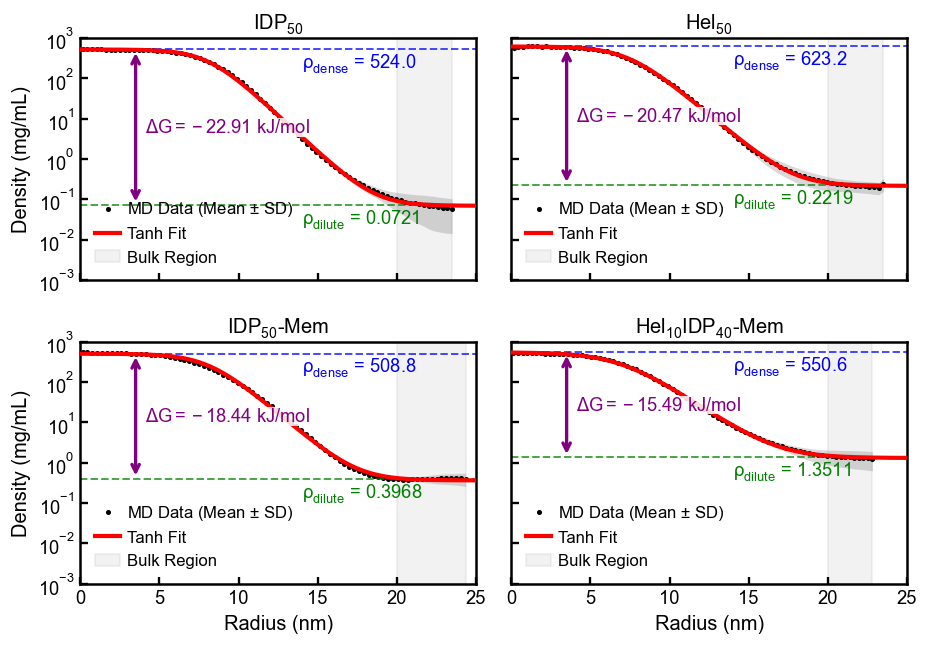

In [46]:
import MDAnalysis as mda
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import sys
from tqdm import tqdm
import warnings
from pathlib import Path
from datetime import datetime
import csv
import json
import hashlib
import pickle

# 忽略警告
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

# ===================== 全局默认参数 =====================
# 如果系统配置里没写，就用这里的默认值
DEFAULT_START_PCT = 0.5
TEMP = 310
GAS_CONST = 0.008314
CONVERSION_FACTOR = 1660.54  # 将分子动力学模拟中的原子单位密度（Dalton/Å³）转换为宏观的质量浓度单位（mg/mL 或 g/L）
n_bins = 80
EXPECTED_PROTEIN_CHAINS = 50

# 输出和缓存位置：从项目根运行时写到 Analysis/density；从 notebook 所在目录运行时写到当前目录。
DENSITY_OUTPUT_DIR = Path("Analysis/density") if Path("Analysis/density/density.ipynb").exists() else Path(".")
RAW_DATA_DIR = DENSITY_OUTPUT_DIR / "plot_raw_data"
CACHE_DIR = DENSITY_OUTPUT_DIR / "cache"
RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

DENSITY_CACHE_VERSION = "density-cache-v3-valid-radius"
DENSITY_CACHE_FILE = CACHE_DIR / "density_analysis_cache_v2.pkl"
USE_DENSITY_CACHE = True
FORCE_RECOMPUTE_DENSITY = False
SAVE_RAW_PLOT_DATA = True
MIN_FIT_COVERAGE = 1.0  # 拟合只使用在所有已分析帧内都有效的 radial bins

# --- Plot configuration（局部补充；字体与风格以 cell1 为准） ---
# 四子图使用 "double_large" 预设（如需调整，修改下面两行）
SUBPLOT_PRESET = "double_large"
MD_POINT_SIZE = 3
TEXT_FONTSIZE = float(plt.rcParams["font.size"])  # 跟随 cell1 的统一字号（当前为 9）
PHASE_LABEL_Y_SCALE = 0.35                          # dense / dilute 文本统一放在对应虚线下方
DELTAG_X_OFFSET = 0.6                              # ΔG 文本放在箭头右侧一点
DELTAG_ZORDER = 20                                # ΔG 文本始终压在最上层

# ===================== 系统配置 =====================
# 在这里为每个系统独立设置 start_pct
systems_config = [
    {
        "title": r"$\text{IDP}_{50}$",
        "start_pct": 0.5,       # 该系统从 50% 处开始计算
        "topo": "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_0/TR_Mdvwhole/pbc.tpr",
        "trajs": [
            "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_0/TR_Mdvwhole/clus_centered.xtc",
            "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_0_re1/TR_Mdvwhole/clus_centered.xtc",
            "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_0_re2/TR_Mdvwhole/clus_centered.xtc"
        ]
    },
    {
        "title": r"$\text{Hel}_{50}$",
        "start_pct": 0.5,       # 该系统平衡较快，从 50% 开始
        "topo": "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_700/TR_Mdvwhole/pbc.tpr",
        "trajs": [
            "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_700/TR_Mdvwhole/clus_centered.xtc",
            "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_700_re1/TR_Mdvwhole/clus_centered.xtc",
            "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_700_re2/TR_Mdvwhole/clus_centered.xtc"
        ]
    },
    {
        "title": r"$\text{IDP}_{50}$-Mem",
        "start_pct": 0,       # 膜系统平衡慢，从 0% 开始
        "topo": "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Onmem/muti_chain/POPC7-POPG3/alhx_0_plus1/TR_Mdvwhole/pbc.tpr",
        "trajs": [
            "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Onmem/muti_chain/POPC7-POPG3/alhx_0_plus1/TR_Mdvwhole/clus_centered.xtc",
            "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Onmem/muti_chain/POPC7-POPG3/alhx_0_plus2/TR_Mdvwhole/clus_centered.xtc",
            "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Onmem/muti_chain/POPC7-POPG3/alhx_0_plus3/TR_Mdvwhole/clus_centered.xtc"
        ]
    },
    {
        "title": r"$\text{Hel}_{10}\text{IDP}_{40}$-Mem",
        "start_pct": 0.5,       # 从 50% 开始
        "topo": "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Onmem/muti_chain/POPC7-POPG3/alhx_700_WALL1/TR_Mdvwhole/pbc.tpr",
        "trajs": [
            "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Onmem/muti_chain/POPC7-POPG3/alhx_700_WALL1/TR_Mdvwhole/clus_centered.xtc",
            "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Onmem/muti_chain/POPC7-POPG3/alhx_700_WALL2/TR_Mdvwhole/clus_centered.xtc",
            "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Onmem/muti_chain/POPC7-POPG3/alhx_700_WALL3/TR_Mdvwhole/clus_centered.xtc"
        ]
    }
]

# ===================== 辅助函数 =====================
def tanh_func(r, rho_d, rho_s, Rc, w):
    return (rho_d + rho_s) / 2 - ((rho_d - rho_s) / 2) * np.tanh(2 * (r - Rc) / w)

def log_tanh(r, rho_d, rho_s, Rc, w):
    return np.log(np.maximum(tanh_func(r, rho_d, rho_s, Rc, w), 1e-8))


def _valid_radius_from_mask(r_nm, mask):
    mask = np.asarray(mask, dtype=bool)
    return float(np.nanmax(r_nm[mask])) if np.any(mask) else np.nan


def fit_delta_g_from_profile(profile, r_nm, fit_mask=None):
    profile = np.asarray(profile, dtype=float)
    eps = 1e-8
    v_profile = (profile > eps) & np.isfinite(profile)
    if fit_mask is not None:
        v_profile &= np.asarray(fit_mask, dtype=bool)
    r_fit_profile = r_nm[v_profile]
    rho_fit_profile = profile[v_profile]

    empty_result = dict(
        deltaG=np.nan,
        rho_dense=np.nan,
        rho_dilute=np.nan,
        Rc=np.nan,
        w=np.nan,
        valid_radius=np.nan,
    )
    if r_fit_profile.size < 5:
        return empty_result

    try:
        p0 = [
            np.clip(np.nanmax(rho_fit_profile), 1e-8, 2499),
            np.clip(np.nanmin(rho_fit_profile), 1e-8, 499),
            np.nanmedian(r_fit_profile),
            3.0,
        ]
        popt_profile, _ = curve_fit(
            log_tanh,
            r_fit_profile,
            np.log(rho_fit_profile),
            p0=p0,
            bounds=(1e-10, [2500, 500, r_fit_profile[-1], 20]),
            maxfev=20000,
        )
        rho_d_profile, rho_s_profile, Rc_profile, w_profile = popt_profile
        delta_g_profile = -GAS_CONST * TEMP * np.log(rho_d_profile / rho_s_profile)
        return dict(
            deltaG=delta_g_profile,
            rho_dense=rho_d_profile,
            rho_dilute=rho_s_profile,
            Rc=Rc_profile,
            w=w_profile,
            valid_radius=_valid_radius_from_mask(r_nm, v_profile),
        )
    except Exception:
        return empty_result


def _as_float(value):
    try:
        return float(value)
    except Exception:
        return np.nan


def _json_ready(value):
    if isinstance(value, dict):
        return {str(k): _json_ready(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [_json_ready(v) for v in value]
    if isinstance(value, np.ndarray):
        return _json_ready(value.tolist())
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        value = float(value)
        return None if not np.isfinite(value) else value
    if isinstance(value, float):
        return None if not np.isfinite(value) else value
    return value


def _write_csv(path, rows, fieldnames=None):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    rows = list(rows)
    if fieldnames is None:
        fieldnames = []
        for row in rows:
            for key in row.keys():
                if key not in fieldnames:
                    fieldnames.append(key)
    with path.open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=fieldnames, extrasaction="ignore")
        writer.writeheader()
        for row in rows:
            writer.writerow({key: _json_ready(row.get(key, "")) for key in fieldnames})
    return path


def _file_fingerprint(path):
    path = Path(path)
    try:
        stat = path.stat()
        return {
            "path": str(path),
            "exists": True,
            "size": int(stat.st_size),
            "mtime_ns": int(stat.st_mtime_ns),
        }
    except FileNotFoundError:
        return {
            "path": str(path),
            "exists": False,
            "size": None,
            "mtime_ns": None,
        }


def build_density_cache_metadata():
    metadata = {
        "cache_version": DENSITY_CACHE_VERSION,
        "n_bins": int(n_bins),
        "temperature_K": float(TEMP),
        "gas_const": float(GAS_CONST),
        "conversion_factor": float(CONVERSION_FACTOR),
        "expected_protein_chains": int(EXPECTED_PROTEIN_CHAINS),
        "min_fit_coverage": float(MIN_FIT_COVERAGE),
        "systems": [],
    }
    for cfg in systems_config:
        metadata["systems"].append({
            "title": cfg["title"],
            "start_pct": float(cfg.get("start_pct", DEFAULT_START_PCT)),
            "topo": _file_fingerprint(cfg["topo"]),
            "trajs": [_file_fingerprint(path) for path in cfg["trajs"]],
        })
    signature_payload = json.dumps(metadata, sort_keys=True, ensure_ascii=True)
    metadata["signature"] = hashlib.sha256(signature_payload.encode("utf-8")).hexdigest()
    return metadata


def load_density_cache(cache_file, metadata):
    cache_file = Path(cache_file)
    if not cache_file.exists():
        print(f"未检测到缓存: {cache_file}")
        return None
    try:
        with cache_file.open("rb") as handle:
            payload = pickle.load(handle)
    except Exception as exc:
        print(f"检测到缓存但读取失败，将重新计算: {exc}")
        return None

    cached_metadata = payload.get("metadata", {})
    if payload.get("version") != DENSITY_CACHE_VERSION:
        print("检测到缓存但版本不同，将重新计算。")
        return None
    if cached_metadata.get("signature") != metadata.get("signature"):
        print("检测到缓存但输入文件或参数已变化，将重新计算。")
        return None

    print(f"检测到可用缓存: {cache_file}")
    print(f"缓存生成时间: {payload.get('created_at', 'unknown')}；跳过 xtc 密度重新计算。")
    return payload


def save_density_cache(cache_file, metadata, free_energy_rows, free_energy_summary, fit_only_profile_rows, chain_diagnostics):
    payload = {
        "version": DENSITY_CACHE_VERSION,
        "created_at": datetime.now().isoformat(timespec="seconds"),
        "metadata": metadata,
        "free_energy_rows": free_energy_rows,
        "free_energy_summary": free_energy_summary,
        "fit_only_profile_rows": fit_only_profile_rows,
        "chain_diagnostics": chain_diagnostics,
    }
    cache_file = Path(cache_file)
    cache_file.parent.mkdir(parents=True, exist_ok=True)
    with cache_file.open("wb") as handle:
        pickle.dump(payload, handle, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"已保存密度分析缓存: {cache_file}")
    return cache_file


def _preview_values(values, n=8):
    arr = np.asarray(values)
    if arr.size == 0:
        return []
    preview = arr[:n].tolist()
    return [int(v) if isinstance(v, (np.integer, int)) else str(v) for v in preview]


def _summarize_numeric(values):
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return "no finite values"
    return f"min/median/max={np.nanmin(arr):.0f}/{np.nanmedian(arr):.0f}/{np.nanmax(arr):.0f}"


def _add_chain_candidate(candidates, method, count, detail="", direct=True, expected=EXPECTED_PROTEIN_CHAINS):
    if count is None:
        return
    try:
        count = int(count)
    except Exception:
        return
    candidates.append({
        "method": method,
        "count": count,
        "matches_expected": count == expected,
        "direct_chain_evidence": bool(direct),
        "detail": detail,
    })


def diagnose_protein_chains(universe, system_title, topology, trajectory, expected=EXPECTED_PROTEIN_CHAINS):
    protein = universe.select_atoms("protein")
    residues = protein.residues
    candidates = []
    notes = []

    _add_chain_candidate(
        candidates,
        "segments",
        protein.n_segments,
        "MDAnalysis protein AtomGroup segments",
        direct=True,
        expected=expected,
    )

    for level_name, obj in [("atoms", protein), ("residues", residues)]:
        for attr in ["molnums", "chainIDs", "segids"]:
            try:
                values = np.asarray(getattr(obj, attr))
            except Exception:
                continue
            if values.size == 0:
                continue
            unique_values = np.unique(values.astype(str))
            _add_chain_candidate(
                candidates,
                f"{level_name}.{attr}",
                unique_values.size,
                f"unique values preview={unique_values[:6].tolist()}",
                direct=True,
                expected=expected,
            )

    try:
        fragments = protein.fragments
        frag_atom_counts = np.array([frag.n_atoms for frag in fragments], dtype=int)
        _add_chain_candidate(
            candidates,
            "bonded fragments",
            len(fragments),
            _summarize_numeric(frag_atom_counts),
            direct=True,
            expected=expected,
        )
    except Exception as exc:
        notes.append(f"bonded fragments unavailable: {type(exc).__name__}: {exc}")

    try:
        resids = np.asarray(residues.resids)
    except Exception:
        resids = np.array([], dtype=int)

    if resids.size:
        unique_resids = np.unique(resids)
        if unique_resids.size > 0 and residues.n_residues % unique_resids.size == 0:
            repeated_sets = residues.n_residues // unique_resids.size
            _add_chain_candidate(
                candidates,
                "repeated residue-id sets",
                repeated_sets,
                f"unique residue IDs={unique_resids.size}",
                direct=False,
                expected=expected,
            )
        try:
            resid_int = resids.astype(int)
            restart_breaks = np.where(np.diff(resid_int) <= 0)[0] + 1
            if restart_breaks.size:
                block_sizes = np.diff(np.r_[0, restart_breaks, residues.n_residues])
                _add_chain_candidate(
                    candidates,
                    "residue-id restart blocks",
                    block_sizes.size,
                    f"residue block sizes {_summarize_numeric(block_sizes)}",
                    direct=False,
                    expected=expected,
                )
        except Exception:
            pass

    expected_chunk = None
    expected_atom_counts = []
    if expected and residues.n_residues % expected == 0:
        expected_chunk = residues.n_residues // expected
        for start in range(0, residues.n_residues, expected_chunk):
            expected_atom_counts.append(residues[start:start + expected_chunk].atoms.n_atoms)
        _add_chain_candidate(
            candidates,
            "expected 50-chain residue chunks",
            expected,
            f"{expected_chunk} residues/chain by equal partition; atom counts {_summarize_numeric(expected_atom_counts)}",
            direct=False,
            expected=expected,
        )

    direct_matches = [c for c in candidates if c["matches_expected"] and c["direct_chain_evidence"]]
    inferred_matches = [c for c in candidates if c["matches_expected"] and not c["direct_chain_evidence"]]
    diag = {
        "system": system_title,
        "topology": str(topology),
        "trajectory_for_probe": str(trajectory),
        "expected_chains": int(expected),
        "protein_atoms": int(protein.n_atoms),
        "protein_residues": int(residues.n_residues),
        "protein_segments": int(protein.n_segments),
        "residue_id_unique_count": int(np.unique(resids).size) if resids.size else 0,
        "residue_id_min": int(np.nanmin(resids.astype(float))) if resids.size else None,
        "residue_id_max": int(np.nanmax(resids.astype(float))) if resids.size else None,
        "residue_id_first": _preview_values(resids, n=10),
        "residue_id_last": _preview_values(resids[-10:], n=10) if resids.size else [],
        "residue_names_preview": _preview_values(residues.resnames, n=10) if residues.n_residues else [],
        "expected_residues_per_chain": int(expected_chunk) if expected_chunk else None,
        "expected_chunk_atom_count_min": int(np.min(expected_atom_counts)) if expected_atom_counts else None,
        "expected_chunk_atom_count_median": float(np.median(expected_atom_counts)) if expected_atom_counts else None,
        "expected_chunk_atom_count_max": int(np.max(expected_atom_counts)) if expected_atom_counts else None,
        "candidate_counts": candidates,
        "direct_methods_matching_expected": [c["method"] for c in direct_matches],
        "inferred_methods_matching_expected": [c["method"] for c in inferred_matches],
        "has_direct_expected_match": bool(direct_matches),
        "has_any_expected_match": bool(direct_matches or inferred_matches),
        "notes": notes,
    }
    return diag


def print_chain_diagnostics(chain_diagnostics, expected=EXPECTED_PROTEIN_CHAINS):
    print("\n================ 蛋白链识别诊断 ================")
    print(f"期望链数: {expected}")
    for diag in chain_diagnostics:
        if diag.get("has_direct_expected_match"):
            status = "OK-direct"
        elif diag.get("has_any_expected_match"):
            status = "CHECK-inferred"
        else:
            status = "CHECK"
        print(f"[{status}] {diag['system']}")
        print(
            "  protein atoms/residues/segments = "
            f"{diag['protein_atoms']}/{diag['protein_residues']}/{diag['protein_segments']}"
        )
        candidate_text = "; ".join(
            f"{c['method']}={c['count']}{'*' if c['matches_expected'] else ''}"
            for c in diag.get("candidate_counts", [])
        )
        print(f"  candidate chain counts (*=50): {candidate_text if candidate_text else 'none'}")
        print(
            "  residue IDs: "
            f"unique={diag['residue_id_unique_count']}, "
            f"range={diag['residue_id_min']}..{diag['residue_id_max']}, "
            f"first={diag['residue_id_first']}, last={diag['residue_id_last']}"
        )
        if diag.get("expected_residues_per_chain") is not None:
            print(
                "  按 50 条链等分校验: "
                f"{diag['expected_residues_per_chain']} residues/chain; "
                "atom counts min/median/max = "
                f"{diag['expected_chunk_atom_count_min']}/"
                f"{diag['expected_chunk_atom_count_median']:.0f}/"
                f"{diag['expected_chunk_atom_count_max']}"
            )
        if diag.get("direct_methods_matching_expected"):
            print(f"  直接支持 50 链的方法: {diag['direct_methods_matching_expected']}")
        if diag.get("inferred_methods_matching_expected"):
            print(f"  间接支持 50 链的方法: {diag['inferred_methods_matching_expected']}")
        for note in diag.get("notes", []):
            print(f"  note: {note}")
    print("说明: direct 表示 MDAnalysis 拓扑属性/键连 fragment 直接给出 50；inferred 表示 residue 编号或总 residue 数支持 50，需要结合体系构建方式判断。")


def save_density_raw_data(fit_rows, energy_rows, energy_summary, chain_diagnostics, raw_dir=RAW_DATA_DIR):
    raw_dir = Path(raw_dir)
    raw_dir.mkdir(parents=True, exist_ok=True)
    saved = []

    mean_profile_rows = []
    replicate_profile_rows = []
    fit_param_rows = []
    for row in fit_rows:
        group = row["group"]
        r_nm = np.asarray(row["r_nm"], dtype=float)
        mean_rho = np.asarray(row["mean_rho"], dtype=float)
        std_rho = np.asarray(row["std_rho"], dtype=float)
        popt = row.get("popt")
        valid_radius_nm = _as_float(row.get("valid_radius", np.nan))
        curve_density = tanh_func(r_nm, *popt) if popt is not None and np.all(np.isfinite(popt)) else np.full_like(r_nm, np.nan)
        if np.isfinite(valid_radius_nm):
            curve_density = np.where(r_nm <= valid_radius_nm, curve_density, np.nan)
        for bin_idx, (r_value, mean_value, sd_value, curve_value) in enumerate(zip(r_nm, mean_rho, std_rho, curve_density)):
            mean_profile_rows.append({
                "group": group,
                "bin": bin_idx,
                "r_nm": r_value,
                "mean_density_mg_ml": mean_value,
                "sd_density_mg_ml": sd_value,
                "curve_density_mg_ml": curve_value,
            })
        replicate_profiles = row.get("replicate_profiles")
        replicate_paths = row.get("replicate_paths", [])
        if replicate_profiles is not None:
            for rep_idx, profile in enumerate(np.asarray(replicate_profiles, dtype=float), start=1):
                traj_path = replicate_paths[rep_idx - 1] if rep_idx - 1 < len(replicate_paths) else ""
                for bin_idx, (r_value, density_value) in enumerate(zip(r_nm, profile)):
                    replicate_profile_rows.append({
                        "group": group,
                        "replicate": rep_idx,
                        "trajectory": traj_path,
                        "bin": bin_idx,
                        "r_nm": r_value,
                        "density_mg_ml": density_value,
                    })
        fit_param_rows.append({
            "group": group,
            "rho_dense_mg_ml": row.get("rho_dense"),
            "rho_dilute_mg_ml": row.get("rho_dilute"),
            "Rc_nm": row.get("Rc"),
            "w_nm": row.get("w"),
            "deltaG_kj_mol": row.get("deltaG"),
            "valid_radius_nm": row.get("valid_radius"),
        })

    saved.append(_write_csv(raw_dir / "density_mean_profile_plot_data.csv", mean_profile_rows))
    saved.append(_write_csv(raw_dir / "density_replicate_profile_plot_data.csv", replicate_profile_rows))
    saved.append(_write_csv(raw_dir / "density_parameters.csv", fit_param_rows))

    energy_fieldnames = [
        "group", "replicate", "deltaG", "rho_dense", "rho_dilute", "Rc", "w", "valid_radius",
    ]
    saved.append(_write_csv(raw_dir / "free_energy_replicates.csv", energy_rows, energy_fieldnames))
    saved.append(_write_csv(raw_dir / "free_energy_summary.csv", energy_summary))

    chain_rows = []
    for diag in chain_diagnostics:
        base = {
            "system": diag["system"],
            "expected_chains": diag["expected_chains"],
            "protein_atoms": diag["protein_atoms"],
            "protein_residues": diag["protein_residues"],
            "protein_segments": diag["protein_segments"],
            "has_direct_expected_match": diag["has_direct_expected_match"],
            "has_any_expected_match": diag["has_any_expected_match"],
            "expected_residues_per_chain": diag["expected_residues_per_chain"],
            "topology": diag["topology"],
            "trajectory_for_probe": diag["trajectory_for_probe"],
        }
        for candidate in diag.get("candidate_counts", []):
            row = dict(base)
            row.update({
                "method": candidate["method"],
                "candidate_count": candidate["count"],
                "matches_expected": candidate["matches_expected"],
                "direct_chain_evidence": candidate["direct_chain_evidence"],
                "detail": candidate["detail"],
            })
            chain_rows.append(row)
    saved.append(_write_csv(raw_dir / "chain_diagnostics.csv", chain_rows))
    chain_json = raw_dir / "chain_diagnostics.json"
    chain_json.write_text(json.dumps(_json_ready(chain_diagnostics), ensure_ascii=False, indent=2), encoding="utf-8")
    saved.append(chain_json)
    return saved


def _prefer_reported_or_legacy_fit(row, reported_key, legacy_fit_key=None):
    if legacy_fit_key is not None:
        legacy_value = _as_float(row.get(legacy_fit_key, np.nan))
        if np.isfinite(legacy_value):
            return legacy_value
    return _as_float(row.get(reported_key, np.nan))


def standardize_density_results(free_energy_rows, free_energy_summary, fit_only_profile_rows):
    """Expose fitted dense/dilute parameters through clean reported keys."""
    for row in free_energy_rows:
        rho_dense = _prefer_reported_or_legacy_fit(row, "rho_dense", "rho_dense_fit")
        rho_dilute = _prefer_reported_or_legacy_fit(row, "rho_dilute", "rho_dilute_fit")
        delta_g = _prefer_reported_or_legacy_fit(row, "deltaG", "deltaG_fit")
        if np.isfinite(rho_dense):
            row["rho_dense"] = rho_dense
        if np.isfinite(rho_dilute):
            row["rho_dilute"] = rho_dilute
        if np.isfinite(delta_g):
            row["deltaG"] = delta_g
        valid_radius = _as_float(row.get("valid_radius", np.nan))
        if np.isfinite(valid_radius):
            row["valid_radius"] = valid_radius

    for row in fit_only_profile_rows:
        rho_dense = _prefer_reported_or_legacy_fit(row, "rho_dense", "rho_dense_fit")
        rho_dilute = _prefer_reported_or_legacy_fit(row, "rho_dilute", "rho_dilute_fit")
        delta_g = _prefer_reported_or_legacy_fit(row, "deltaG", "deltaG_fit")
        if np.isfinite(rho_dense):
            row["rho_dense"] = rho_dense
        if np.isfinite(rho_dilute):
            row["rho_dilute"] = rho_dilute
        if np.isfinite(delta_g):
            row["deltaG"] = delta_g
        valid_radius = _as_float(row.get("valid_radius", np.nan))
        if np.isfinite(valid_radius):
            row["valid_radius"] = valid_radius

    profile_by_group = {row.get("group"): row for row in fit_only_profile_rows}
    group_order = [cfg["title"] for cfg in systems_config]
    for row in free_energy_rows:
        group = row.get("group")
        if group not in group_order:
            group_order.append(group)

    density_summary = []
    for group in group_order:
        replicate_delta_g = np.array([
            _as_float(row.get("deltaG", np.nan))
            for row in free_energy_rows
            if row.get("group") == group
        ], dtype=float)
        replicate_delta_g = replicate_delta_g[np.isfinite(replicate_delta_g)]
        profile_delta_g = _as_float(profile_by_group.get(group, {}).get("deltaG", np.nan))
        density_summary.append({
            "group": group,
            "mean_deltaG": np.nanmean(replicate_delta_g) if replicate_delta_g.size else np.nan,
            "sd_deltaG": np.nanstd(replicate_delta_g, ddof=1) if replicate_delta_g.size > 1 else 0.0,
            "n": int(replicate_delta_g.size),
            "mean_profile_deltaG": profile_delta_g,
        })

    return free_energy_rows, density_summary, fit_only_profile_rows


# ===================== 计算或读取缓存 =====================
density_cache_metadata = build_density_cache_metadata()
cache_payload = None
if USE_DENSITY_CACHE and not FORCE_RECOMPUTE_DENSITY:
    cache_payload = load_density_cache(DENSITY_CACHE_FILE, density_cache_metadata)
elif FORCE_RECOMPUTE_DENSITY:
    print("FORCE_RECOMPUTE_DENSITY=True：忽略已有缓存，重新计算。")

if cache_payload is not None:
    free_energy_rows = cache_payload["free_energy_rows"]
    free_energy_summary = cache_payload["free_energy_summary"]
    fit_only_profile_rows = cache_payload["fit_only_profile_rows"]
    chain_diagnostics = cache_payload.get("chain_diagnostics", [])
else:
    print("没有可用缓存，开始从轨迹重新计算密度。")
    # 保存每个 replicate 的自由能，用于后续柱状图 + error bar + 散点
    free_energy_rows = []
    free_energy_summary = []

    # 保存四组 mean profile 和拟合得到的相浓度，用于汇总图
    fit_only_profile_rows = []
    chain_diagnostics = []

    for idx, sys_info in enumerate(systems_config):
        # 提取该系统特有的参数，如果没有设置，则使用全局默认值
        current_start_pct = sys_info.get("start_pct", DEFAULT_START_PCT)

        print(f"\nProcessing {sys_info['title']} (Start from: {current_start_pct*100:.0f}%)")

        # 1. 计算密度，并先输出链识别诊断
        u_init = mda.Universe(sys_info["topo"], sys_info["trajs"][0])
        diag = diagnose_protein_chains(u_init, sys_info["title"], sys_info["topo"], sys_info["trajs"][0])
        chain_diagnostics.append(diag)
        candidate_counts = ", ".join(
            f"{c['method']}={c['count']}{'*' if c['matches_expected'] else ''}"
            for c in diag.get("candidate_counts", [])
        )
        print(
            f"  Chain probe: protein atoms={diag['protein_atoms']}, residues={diag['protein_residues']}, "
            f"segments={diag['protein_segments']}; candidates: {candidate_counts}"
        )
        if diag.get("has_direct_expected_match"):
            print("  Chain probe verdict: 直接拓扑/fragment 信息支持 50 条蛋白链。")
        elif diag.get("has_any_expected_match"):
            print("  Chain probe verdict: residue 编号/总数间接支持 50 条链，请结合构建方式确认。")
        else:
            print("  Chain probe verdict: 未找到支持 50 链的候选计数，需要检查 selection/topology。")

        r_max = np.min(u_init.dimensions[:3]) / 2.0
        bins = np.linspace(0, r_max, n_bins + 1)
        bin_centers = 0.5 * (bins[:-1] + bins[1:])
        volumes = 4 / 3 * np.pi * (bins[1:]**3 - bins[:-1]**3)

        all_profiles = []
        profile_fit_masks = []
        replicate_valid_radii = []
        for rep_idx, traj in enumerate(sys_info["trajs"], start=1):
            u = mda.Universe(sys_info["topo"], traj)
            sel = u.select_atoms("protein")
            mass_arr = sel.masses
            t_mass = np.zeros(n_bins)
            b_count = np.zeros(n_bins)

            # 使用当前系统的 start_pct
            total_frames = len(u.trajectory)
            start_frame = int(total_frames * current_start_pct)
            print(
                f"  Rep {rep_idx}: frames={total_frames}, start_frame={start_frame}, "
                f"used_frames={total_frames - start_frame}, protein_atoms={sel.n_atoms}, protein_residues={sel.n_residues}"
            )

            for ts in tqdm(u.trajectory[start_frame:], desc=f"  Traj {rep_idx}", leave=False):
                safe_r = np.min(ts.dimensions[:3]) / 2.0
                dists = np.linalg.norm(sel.positions, axis=1)
                m_counts, _ = np.histogram(dists, bins=bins, weights=mass_arr)
                mask = bins[1:] <= safe_r
                t_mass[mask] += m_counts[mask]
                b_count[mask] += 1

            dens = np.zeros(n_bins)
            v = b_count > 0
            dens[v] = (t_mass[v] / b_count[v] / volumes[v]) * CONVERSION_FACTOR
            dens[~v] = np.nan
            used_frame_count = max(total_frames - start_frame, 0)
            coverage = np.divide(
                b_count,
                used_frame_count,
                out=np.zeros_like(b_count, dtype=float),
                where=used_frame_count > 0,
            )
            fit_mask = v & (coverage >= MIN_FIT_COVERAGE)
            valid_radius_nm = _valid_radius_from_mask(bin_centers / 10.0, fit_mask)
            profile_fit_masks.append(fit_mask)
            replicate_valid_radii.append(valid_radius_nm)
            print(f"  Rep {rep_idx}: valid_radius={valid_radius_nm:.2f} nm (coverage >= {MIN_FIT_COVERAGE:.2f})")
            all_profiles.append(dens)
            try:
                u.trajectory.close()
            except Exception:
                pass

        all_profiles = np.array(all_profiles)
        profile_fit_masks = np.array(profile_fit_masks, dtype=bool)
        common_fit_mask = np.all(profile_fit_masks, axis=0) if profile_fit_masks.size else np.zeros(n_bins, dtype=bool)
        mean_rho = np.nanmean(all_profiles, axis=0)
        std_rho = np.nanstd(all_profiles, axis=0)
        r_nm = bin_centers / 10.0

        # 对每个 replicate 单独拟合自由能，作为柱状图的散点和误差来源
        replicate_results = []
        for rep_idx, profile in enumerate(all_profiles, start=1):
            rep_result = fit_delta_g_from_profile(profile, r_nm, profile_fit_masks[rep_idx - 1])
            rep_result.update({"group": sys_info["title"], "replicate": rep_idx})
            free_energy_rows.append(rep_result)
            replicate_results.append(rep_result)

        # 2. 拟合与参数计算
        eps = 1e-8
        v_mask = (mean_rho > eps) & (~np.isnan(mean_rho)) & common_fit_mask
        r_fit = r_nm[v_mask]
        rho_fit = mean_rho[v_mask]

        rho_d_f = rho_s_f = Rc_f = w_f = np.nan
        rho_s_avg = deltaG = valid_radius_nm = np.nan
        popt = None
        if r_fit.size >= 5:
            try:
                p0 = [np.max(rho_fit), np.min(rho_fit), np.median(r_fit), 3.0]
                popt, _ = curve_fit(
                    log_tanh,
                    r_fit,
                    np.log(rho_fit),
                    p0=p0,
                    bounds=(1e-10, [2500, 500, r_fit[-1], 20]),
                    maxfev=20000,
                )
                rho_d_f, rho_s_f, Rc_f, w_f = popt

                # 稀相浓度和自由能直接使用 tanh 拟合参数
                valid_radius_nm = _valid_radius_from_mask(r_nm, v_mask)
                rho_s_avg = rho_s_f
                deltaG = -GAS_CONST * TEMP * np.log(rho_d_f / rho_s_f)
            except Exception as exc:
                print(f"  Fit failed for {sys_info['title']}: {exc}")
                popt = None
        else:
            print(f"  Fit skipped for {sys_info['title']}: valid profile points < 5")

        replicate_delta_g = np.array([res["deltaG"] for res in replicate_results], dtype=float)
        replicate_delta_g = replicate_delta_g[np.isfinite(replicate_delta_g)]
        free_energy_summary.append({
            "group": sys_info["title"],
            "mean_deltaG": np.nanmean(replicate_delta_g) if replicate_delta_g.size else np.nan,
            "sd_deltaG": np.nanstd(replicate_delta_g, ddof=1) if replicate_delta_g.size > 1 else 0.0,
            "n": int(replicate_delta_g.size),
            "mean_profile_deltaG": deltaG,
            "mean_profile_valid_radius_nm": valid_radius_nm,
        })

        fit_only_profile_rows.append({
            "group": sys_info["title"],
            "r_nm": r_nm.copy(),
            "mean_rho": mean_rho.copy(),
            "std_rho": std_rho.copy(),
            "replicate_profiles": all_profiles.copy(),
            "replicate_paths": list(sys_info["trajs"]),
            "popt": None if popt is None else np.array(popt, dtype=float),
            "rho_dense": rho_d_f,
            "rho_dilute": rho_s_f,
            "Rc": Rc_f,
            "w": w_f,
            "deltaG": deltaG,
            "valid_radius": valid_radius_nm,
            "replicate_valid_radii": np.array(replicate_valid_radii, dtype=float),
            "profile_fit_masks": profile_fit_masks.copy(),
        })

    save_density_cache(
        DENSITY_CACHE_FILE,
        density_cache_metadata,
        free_energy_rows,
        free_energy_summary,
        fit_only_profile_rows,
        chain_diagnostics,
    )

free_energy_rows, free_energy_summary, fit_only_profile_rows = standardize_density_results(
    free_energy_rows,
    free_energy_summary,
    fit_only_profile_rows,
)
if cache_payload is not None:
    print("已将缓存中的 rho_dense / rho_dilute / Delta G 主结果切换为 clean 拟合口径。")

if SAVE_RAW_PLOT_DATA:
    saved_raw_paths = save_density_raw_data(
        fit_only_profile_rows,
        free_energy_rows,
        free_energy_summary,
        chain_diagnostics,
        RAW_DATA_DIR,
    )
    print("\n已保存/刷新绘图原始数据:")
    for saved_path in saved_raw_paths:
        print(f"  - {saved_path}")

print_chain_diagnostics(chain_diagnostics)

# ===================== 主绘图循环（使用新计算结果或缓存结果） =====================
fit_rows_by_group = {row["group"]: row for row in fit_only_profile_rows}
fig, axes = new_subplots(2, 2, preset=SUBPLOT_PRESET)
axes = axes.flatten()

for idx, sys_info in enumerate(systems_config):
    ax = axes[idx]
    row = fit_rows_by_group[sys_info["title"]]
    r_nm = np.asarray(row["r_nm"], dtype=float)
    mean_rho = np.asarray(row["mean_rho"], dtype=float)
    std_rho = np.asarray(row["std_rho"], dtype=float)
    popt = row.get("popt")
    rho_d_f = row.get("rho_dense", np.nan)
    rho_s_avg = row.get("rho_dilute", np.nan)
    deltaG = row.get("deltaG", np.nan)
    valid_radius_nm = _as_float(row.get("valid_radius", np.nan))
    x_max = 25.0

    # 3. 绘图
    ax.set_yscale("log")
    ax.set_ylim(1e-3, 1e3)
    ax.set_xlim(0, x_max)
    ax.yaxis.set_minor_locator(mpl.ticker.NullLocator())

    if row.get("replicate_profiles") is not None and len(row.get("replicate_profiles")) > 1:
        lower = np.maximum(mean_rho - std_rho, 1e-7)
        ax.fill_between(r_nm, lower, mean_rho + std_rho, color="gray", alpha=0.3, lw=0, zorder=1)
    ax.scatter(r_nm, mean_rho, color="black", s=MD_POINT_SIZE, label=r"MD Data (Mean $\pm$ SD)", zorder=2)

    if np.isfinite(valid_radius_nm) and valid_radius_nm < x_max:
        ax.axvspan(valid_radius_nm, x_max, color="0.85", alpha=0.35, lw=0, label="outside valid radius", zorder=0)
        ax.axvline(valid_radius_nm, color="0.45", ls=":", lw=1.0, alpha=0.8, zorder=4)

    if popt is not None and np.all(np.isfinite(popt)):
        curve_x_max = min(x_max, valid_radius_nm) if np.isfinite(valid_radius_nm) and valid_radius_nm > 0 else x_max
        r_smooth = np.linspace(0, curve_x_max, 500)
        ax.plot(r_smooth, tanh_func(r_smooth, *popt), color="red", lw=2.5, label="Density curve", zorder=5)

        ax.axhline(rho_d_f, color="blue", ls="--", lw=1.2, alpha=0.7)
        ax.text(14, rho_d_f * PHASE_LABEL_Y_SCALE, fr"$\rho_{{dense}}$ = {rho_d_f:.1f}", color="blue", fontweight="bold", fontsize=TEXT_FONTSIZE)

        ax.axhline(rho_s_avg, color="green", ls="--", lw=1.2, alpha=0.7)
        ax.text(14, rho_s_avg * PHASE_LABEL_Y_SCALE, fr"$\rho_{{dilute}}$ = {rho_s_avg:.4f}", color="green", fontweight="bold", fontsize=TEXT_FONTSIZE)

        arrow_x = 3.5
        ax.annotate("", xy=(arrow_x, rho_s_avg), xytext=(arrow_x, rho_d_f),
                     arrowprops=dict(arrowstyle="<->", color="purple", lw=2))
        ax.text(arrow_x + DELTAG_X_OFFSET, np.sqrt(rho_d_f * rho_s_avg),
                 fr"$\Delta G_{{\mathrm{{app}}}} = {deltaG:.2f}$ kJ/mol", color="purple", fontweight="bold",
                 ha="left", va="center", fontsize=TEXT_FONTSIZE, zorder=DELTAG_ZORDER,
                 bbox=dict(facecolor="white", alpha=0.85, edgecolor="none", pad=0.2))

    ax.set_title(f"{sys_info['title']}")
    if idx < 2:
        ax.set_xlabel("")
        ax.tick_params(labelbottom=False)
    else:
        ax.set_xlabel("Radius (nm)")
    if idx % 2 == 0:
        ax.set_ylabel("Density (mg/mL)")
    else:
        ax.set_ylabel("")
        ax.tick_params(labelleft=False)
    ax.legend(loc="lower left")

plt.tight_layout()
fig.savefig(DENSITY_OUTPUT_DIR / "combined_custom_start_plots.png", dpi=600, bbox_inches="tight", pad_inches=0.02)
plt.show()


已保存自由能柱状图原始数据: plot_raw_data/free_energy_bar_plot_summary.csv
已保存自由能散点原始数据: plot_raw_data/free_energy_bar_plot_replicates.csv


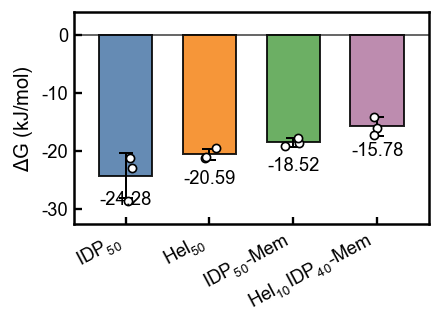

$\mathrm{IDP}_{50}$: -24.28 ± 3.87 kJ/mol (n=3)
$\mathrm{Hel}_{50}$: -20.59 ± 0.96 kJ/mol (n=3)
$\mathrm{IDP}_{50}$-Mem: -18.52 ± 0.75 kJ/mol (n=3)
$\mathrm{Hel}_{10}\mathrm{IDP}_{40}$-Mem: -15.78 ± 1.59 kJ/mol (n=3)


In [47]:
# ===================== 自由能柱状对比图 =====================
# 散点为各 replicate 的 ΔG，柱子为 mean ± SD。
# 优先使用内存中的 free_energy_rows；没有时从 plot_raw_data/free_energy_replicates.csv 读取，
# 因此已有数据时无需运行前面的轨迹密度分析 cell。
from pathlib import Path
import csv
import numpy as np
import matplotlib.pyplot as plt


def _resolve_density_output_dir():
    candidates = []
    if "DENSITY_OUTPUT_DIR" in globals():
        candidates.append(Path(DENSITY_OUTPUT_DIR))
    candidates.extend([Path("Analysis/density"), Path(".")])
    for candidate in candidates:
        if (candidate / "plot_raw_data").exists() or (candidate / "density.ipynb").exists():
            return candidate
    return candidates[0] if candidates else Path(".")


DENSITY_OUTPUT_DIR = _resolve_density_output_dir()
RAW_DATA_DIR = globals().get("RAW_DATA_DIR", DENSITY_OUTPUT_DIR / "plot_raw_data")
RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)


def _read_csv_rows(path):
    path = Path(path)
    with path.open(newline="", encoding="utf-8") as handle:
        return list(csv.DictReader(handle))


def _plot_float(value):
    if value is None or value == "":
        return np.nan
    try:
        return float(value)
    except Exception:
        return np.nan


def _plot_int(value):
    if value is None or value == "":
        return 0
    try:
        return int(float(value))
    except Exception:
        return 0


def _load_free_energy_rows_from_csv(path=None):
    path = Path(path) if path is not None else RAW_DATA_DIR / "free_energy_replicates.csv"
    numeric_keys = [
        "deltaG", "rho_dense", "rho_dilute", "deltaG_fit",
        "rho_dilute_fit", "Rc", "w", "valid_radius",
    ]
    loaded = []
    for raw in _read_csv_rows(path):
        row = dict(raw)
        for key in numeric_keys:
            if key in row:
                row[key] = _plot_float(row[key])
        if "replicate" in row:
            row["replicate"] = _plot_int(row["replicate"])
        if np.isfinite(row.get("rho_dilute_fit", np.nan)):
            row["rho_dilute"] = row["rho_dilute_fit"]
        if np.isfinite(row.get("deltaG_fit", np.nan)):
            row["deltaG"] = row["deltaG_fit"]
        loaded.append(row)
    return loaded


def _ensure_free_energy_plot_inputs():
    global free_energy_rows, systems_config
    if "free_energy_rows" not in globals() or len(free_energy_rows) == 0:
        csv_path = RAW_DATA_DIR / "free_energy_replicates.csv"
        if not csv_path.exists():
            raise RuntimeError(
                f"未找到已有绘图数据: {csv_path}。请先运行四组密度分析 cell 一次以生成数据。"
            )
        free_energy_rows = _load_free_energy_rows_from_csv(csv_path)
        print(f"已从已有数据读取 free_energy_rows: {csv_path}；跳过轨迹密度计算。")

    if "systems_config" not in globals() or len(systems_config) == 0:
        group_titles = []
        for row in free_energy_rows:
            group = row.get("group")
            if group and group not in group_titles:
                group_titles.append(group)
        systems_config = [{"title": group} for group in group_titles]
        print("已根据已有数据恢复 group 顺序。")


_ensure_free_energy_plot_inputs()

if "new_subplots" not in globals():
    raise RuntimeError("请先运行第一个统一绘图风格 cell，再运行这个绘图 cell。")
if "_json_ready" not in globals():
    def _json_ready(value):
        if isinstance(value, dict):
            return {str(k): _json_ready(v) for k, v in value.items()}
        if isinstance(value, (list, tuple)):
            return [_json_ready(v) for v in value]
        if isinstance(value, np.ndarray):
            return _json_ready(value.tolist())
        if isinstance(value, (np.integer,)):
            return int(value)
        if isinstance(value, (np.floating,)):
            value = float(value)
            return None if not np.isfinite(value) else value
        if isinstance(value, float):
            return None if not np.isfinite(value) else value
        return value

if "_write_csv" not in globals():
    def _write_csv(path, rows, fieldnames=None):
        path = Path(path)
        path.parent.mkdir(parents=True, exist_ok=True)
        rows = list(rows)
        if fieldnames is None:
            fieldnames = []
            for row in rows:
                for key in row.keys():
                    if key not in fieldnames:
                        fieldnames.append(key)
        with path.open("w", newline="", encoding="utf-8") as handle:
            writer = csv.DictWriter(handle, fieldnames=fieldnames, extrasaction="ignore")
            writer.writeheader()
            for row in rows:
                writer.writerow({key: _json_ready(row.get(key, "")) for key in fieldnames})
        return path


group_order = [cfg["title"] for cfg in systems_config]
bar_labels = [
    r"$\mathrm{IDP}_{50}$",
    r"$\mathrm{Hel}_{50}$",
    r"$\mathrm{IDP}_{50}$-Mem",
    r"$\mathrm{Hel}_{10}\mathrm{IDP}_{40}$-Mem",
]
bar_colors = ["#4C78A8", "#F58518", "#54A24B", "#B279A2"]
BAR_TEXT_FONTSIZE = globals().get("TEXT_FONTSIZE", float(plt.rcParams["font.size"]))

delta_g_by_group = []
means = []
errors = []
counts = []
for group in group_order:
    values = np.array([
        row["deltaG"]
        for row in free_energy_rows
        if row["group"] == group and np.isfinite(row["deltaG"])
    ], dtype=float)
    delta_g_by_group.append(values)
    means.append(np.nanmean(values) if values.size else np.nan)
    errors.append(np.nanstd(values, ddof=1) if values.size > 1 else 0.0)
    counts.append(values.size)

means = np.array(means, dtype=float)
errors = np.array(errors, dtype=float)

free_energy_bar_summary_rows = []
free_energy_bar_replicate_rows = []
for group, label, mean_value, error_value, count, values in zip(group_order, bar_labels, means, errors, counts, delta_g_by_group):
    free_energy_bar_summary_rows.append({
        "group": group,
        "plot_label": label,
        "mean_deltaG_kj_mol": mean_value,
        "sd_deltaG_kj_mol": error_value,
        "n": int(count),
    })
    for rep_idx, value in enumerate(values, start=1):
        free_energy_bar_replicate_rows.append({
            "group": group,
            "plot_label": label,
            "replicate": rep_idx,
            "deltaG_kj_mol": value,
        })
_write_csv(RAW_DATA_DIR / "free_energy_bar_plot_summary.csv", free_energy_bar_summary_rows)
_write_csv(RAW_DATA_DIR / "free_energy_bar_plot_replicates.csv", free_energy_bar_replicate_rows)
print(f"已保存自由能柱状图原始数据: {RAW_DATA_DIR / 'free_energy_bar_plot_summary.csv'}")
print(f"已保存自由能散点原始数据: {RAW_DATA_DIR / 'free_energy_bar_plot_replicates.csv'}")

fig, ax = new_subplots(1, 1, preset="single_medium")
x = np.arange(len(group_order))
ax.bar(
    x,
    means,
    yerr=errors,
    width=0.64,
    color=bar_colors,
    edgecolor="black",
    linewidth=1.2,
    alpha=0.86,
    capsize=4,
    error_kw=dict(ecolor="black", lw=1.2, capthick=1.2),
    zorder=2,
)

rng = np.random.default_rng(7)
for i, values in enumerate(delta_g_by_group):
    if values.size == 0:
        continue
    jitter = rng.uniform(-0.10, 0.10, size=values.size)
    ax.scatter(
        np.full(values.size, x[i]) + jitter,
        values,
        s=24,
        facecolor="white",
        edgecolor="black",
        linewidth=1.0,
        zorder=4,
    )

ax.axhline(0, color="black", lw=1.0, alpha=0.7, zorder=1)
ax.set_xticks(x)
ax.set_xticklabels(bar_labels, rotation=28, ha="right")
ax.set_ylabel(r"$\Delta G_{\mathrm{app}}$ (kJ/mol)")
#ax.set_title(r"$\Delta G$ comparison")
ax.margins(x=0.08)

finite_arrays = [values for values in delta_g_by_group if values.size]
finite_values = np.concatenate(finite_arrays) if finite_arrays else np.array([], dtype=float)
finite_values = finite_values[np.isfinite(finite_values)]
if finite_values.size:
    lower = min(np.nanmin(finite_values), np.nanmin(means - errors))
    upper = max(np.nanmax(finite_values), np.nanmax(means + errors), 0)
    margin = max((upper - lower) * 0.14, 0.5)
    ax.set_ylim(lower - margin, upper + margin)

for i, (mean_value, error_value, count) in enumerate(zip(means, errors, counts)):
    if not np.isfinite(mean_value):
        continue
    label_y = mean_value - 0.07 * np.diff(ax.get_ylim())[0] if mean_value < 0 else mean_value + 0.04 * np.diff(ax.get_ylim())[0]
    label_va = "top" if mean_value < 0 else "bottom"
    ax.text(
        x[i],
        label_y,
        f"{mean_value:.2f}",
        ha="center",
        va=label_va,
        fontsize=BAR_TEXT_FONTSIZE,
        fontweight="bold",
        zorder=5,
    )

fig.subplots_adjust(left=0.20, right=0.95, bottom=0.34, top=0.94)
fig.savefig(DENSITY_OUTPUT_DIR / "free_energy_bar_comparison.png", dpi=600)
fig.savefig(DENSITY_OUTPUT_DIR / "free_energy_bar_comparison.pdf")
plt.show()

for label, mean_value, error_value, count in zip(bar_labels, means, errors, counts):
    print(f"{label}: {mean_value:.2f} ± {error_value:.2f} kJ/mol (n={count})")


已保存浓/稀相柱状图原始数据: plot_raw_data/phase_concentration_bar_plot_summary.csv
已保存浓/稀相散点原始数据: plot_raw_data/phase_concentration_bar_plot_replicates.csv


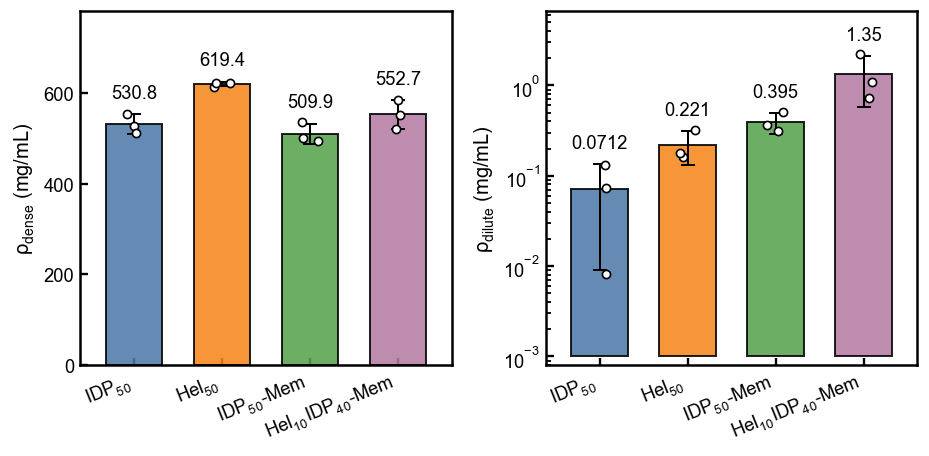

$\mathrm{IDP}_{50}$: rho_dense = 530.8 ± 22.0 mg/mL (n=3); rho_dilute = 0.0712 ± 0.0623 mg/mL (n=3)
$\mathrm{Hel}_{50}$: rho_dense = 619.4 ± 4.95 mg/mL (n=3); rho_dilute = 0.221 ± 0.0897 mg/mL (n=3)
$\mathrm{IDP}_{50}$-Mem: rho_dense = 509.9 ± 22.4 mg/mL (n=3); rho_dilute = 0.395 ± 0.103 mg/mL (n=3)
$\mathrm{Hel}_{10}\mathrm{IDP}_{40}$-Mem: rho_dense = 552.7 ± 31.7 mg/mL (n=3); rho_dilute = 1.35 ± 0.77 mg/mL (n=3)


In [69]:
# ===================== 浓相和稀相浓度统计图 =====================
# 散点为各 replicate 的拟合浓度，柱子为 mean ± SD。
# 优先使用内存中的 free_energy_rows；没有时从 plot_raw_data/free_energy_replicates.csv 读取，
# 因此已有数据时无需运行前面的轨迹密度分析 cell。
from pathlib import Path
import csv
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator


def _resolve_density_output_dir():
    candidates = []
    if "DENSITY_OUTPUT_DIR" in globals():
        candidates.append(Path(DENSITY_OUTPUT_DIR))
    candidates.extend([Path("Analysis/density"), Path(".")])
    for candidate in candidates:
        if (candidate / "plot_raw_data").exists() or (candidate / "density.ipynb").exists():
            return candidate
    return candidates[0] if candidates else Path(".")


DENSITY_OUTPUT_DIR = _resolve_density_output_dir()
RAW_DATA_DIR = globals().get("RAW_DATA_DIR", DENSITY_OUTPUT_DIR / "plot_raw_data")
RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)


def _read_csv_rows(path):
    path = Path(path)
    with path.open(newline="", encoding="utf-8") as handle:
        return list(csv.DictReader(handle))


def _plot_float(value):
    if value is None or value == "":
        return np.nan
    try:
        return float(value)
    except Exception:
        return np.nan


def _plot_int(value):
    if value is None or value == "":
        return 0
    try:
        return int(float(value))
    except Exception:
        return 0


def _load_free_energy_rows_from_csv(path=None):
    path = Path(path) if path is not None else RAW_DATA_DIR / "free_energy_replicates.csv"
    numeric_keys = [
        "deltaG", "rho_dense", "rho_dilute", "deltaG_fit",
        "rho_dilute_fit", "Rc", "w", "valid_radius",
    ]
    loaded = []
    for raw in _read_csv_rows(path):
        row = dict(raw)
        for key in numeric_keys:
            if key in row:
                row[key] = _plot_float(row[key])
        if "replicate" in row:
            row["replicate"] = _plot_int(row["replicate"])
        if np.isfinite(row.get("rho_dilute_fit", np.nan)):
            row["rho_dilute"] = row["rho_dilute_fit"]
        if np.isfinite(row.get("deltaG_fit", np.nan)):
            row["deltaG"] = row["deltaG_fit"]
        loaded.append(row)
    return loaded


def _ensure_free_energy_plot_inputs():
    global free_energy_rows, systems_config
    if "free_energy_rows" not in globals() or len(free_energy_rows) == 0:
        csv_path = RAW_DATA_DIR / "free_energy_replicates.csv"
        if not csv_path.exists():
            raise RuntimeError(
                f"未找到已有绘图数据: {csv_path}。请先运行四组密度分析 cell 一次以生成数据。"
            )
        free_energy_rows = _load_free_energy_rows_from_csv(csv_path)
        print(f"已从已有数据读取 free_energy_rows: {csv_path}；跳过轨迹密度计算。")

    if "systems_config" not in globals() or len(systems_config) == 0:
        group_titles = []
        for row in free_energy_rows:
            group = row.get("group")
            if group and group not in group_titles:
                group_titles.append(group)
        systems_config = [{"title": group} for group in group_titles]
        print("已根据已有数据恢复 group 顺序。")


_ensure_free_energy_plot_inputs()

if "new_subplots" not in globals():
    raise RuntimeError("请先运行第一个统一绘图风格 cell，再运行这个绘图 cell。")
if "_json_ready" not in globals():
    def _json_ready(value):
        if isinstance(value, dict):
            return {str(k): _json_ready(v) for k, v in value.items()}
        if isinstance(value, (list, tuple)):
            return [_json_ready(v) for v in value]
        if isinstance(value, np.ndarray):
            return _json_ready(value.tolist())
        if isinstance(value, (np.integer,)):
            return int(value)
        if isinstance(value, (np.floating,)):
            value = float(value)
            return None if not np.isfinite(value) else value
        if isinstance(value, float):
            return None if not np.isfinite(value) else value
        return value

if "_write_csv" not in globals():
    def _write_csv(path, rows, fieldnames=None):
        path = Path(path)
        path.parent.mkdir(parents=True, exist_ok=True)
        rows = list(rows)
        if fieldnames is None:
            fieldnames = []
            for row in rows:
                for key in row.keys():
                    if key not in fieldnames:
                        fieldnames.append(key)
        with path.open("w", newline="", encoding="utf-8") as handle:
            writer = csv.DictWriter(handle, fieldnames=fieldnames, extrasaction="ignore")
            writer.writeheader()
            for row in rows:
                writer.writerow({key: _json_ready(row.get(key, "")) for key in fieldnames})
        return path


group_order = [cfg["title"] for cfg in systems_config]
phase_bar_labels = [
    r"$\mathrm{IDP}_{50}$",
    r"$\mathrm{Hel}_{50}$",
    r"$\mathrm{IDP}_{50}$-Mem",
    r"$\mathrm{Hel}_{10}\mathrm{IDP}_{40}$-Mem",
]
phase_bar_colors = ["#4C78A8", "#F58518", "#54A24B", "#B279A2"]
PHASE_TEXT_FONTSIZE = globals().get("TEXT_FONTSIZE", float(plt.rcParams["font.size"]))

def collect_phase_values(key):
    values_by_group = []
    for group in group_order:
        values = np.array([
            row[key]
            for row in free_energy_rows
            if row["group"] == group and np.isfinite(row[key]) and row[key] > 0
        ], dtype=float)
        values_by_group.append(values)
    return values_by_group

def summarize_values(values_by_group):
    means = np.array([np.nanmean(values) if values.size else np.nan for values in values_by_group], dtype=float)
    sds = np.array([np.nanstd(values, ddof=1) if values.size > 1 else 0.0 for values in values_by_group], dtype=float)
    counts = np.array([values.size for values in values_by_group], dtype=int)
    return means, sds, counts

def format_concentration(value):
    if not np.isfinite(value):
        return "nan"
    if abs(value) >= 10:
        return f"{value:.1f}"
    if abs(value) >= 1:
        return f"{value:.2f}"
    return f"{value:.3g}"

def draw_phase_bars(ax, key, title, ylabel, use_log=False):
    values_by_group = collect_phase_values(key)
    means, sds, counts = summarize_values(values_by_group)
    x = np.arange(len(group_order))
    finite_arrays = [values for values in values_by_group if values.size]
    finite_values = np.concatenate(finite_arrays) if finite_arrays else np.array([], dtype=float)
    finite_values = finite_values[np.isfinite(finite_values) & (finite_values > 0)]

    if finite_values.size == 0:
        ax.text(0.5, 0.5, "No valid data", transform=ax.transAxes, ha="center", va="center")
        ax.set_axis_off()
        return means, sds, counts

    if use_log:
        bar_bottom = 10 ** np.floor(np.log10(np.nanmin(finite_values) * 0.5))
        heights = np.maximum(means - bar_bottom, bar_bottom * 0.05)
        lower_err = np.minimum(sds, np.maximum(means - bar_bottom * 1.05, 0))
        yerr = np.vstack([lower_err, sds])
        ax.bar(
            x,
            heights,
            bottom=bar_bottom,
            yerr=yerr,
            width=0.64,
            color=phase_bar_colors,
            edgecolor="black",
            linewidth=1.2,
            alpha=0.86,
            capsize=4,
            error_kw=dict(ecolor="black", lw=1.2, capthick=1.2),
            zorder=2,
        )
        ax.set_yscale("log")
        upper = max(np.nanmax(finite_values), np.nanmax(means + sds))
        ax.set_ylim(bar_bottom * 0.8, upper * (3.0 if key == "rho_dilute" else 2.2))
    else:
        ax.bar(
            x,
            means,
            yerr=sds,
            width=0.64,
            color=phase_bar_colors,
            edgecolor="black",
            linewidth=1.2,
            alpha=0.86,
            capsize=4,
            error_kw=dict(ecolor="black", lw=1.2, capthick=1.2),
            zorder=2,
        )
        upper = max(np.nanmax(finite_values), np.nanmax(means + sds))
        ax.set_ylim(0, upper * 1.25)
        if key == "rho_dense":
            ax.yaxis.set_major_locator(MultipleLocator(200))

    rng = np.random.default_rng(11 if key == "rho_dense" else 13)
    for i, values in enumerate(values_by_group):
        if values.size == 0:
            continue
        jitter = rng.uniform(-0.10, 0.10, size=values.size)
        ax.scatter(
            np.full(values.size, x[i]) + jitter,
            values,
            s=24,
            facecolor="white",
            edgecolor="black",
            linewidth=1.0,
            zorder=4,
        )

    for i, (mean_value, sd_value) in enumerate(zip(means, sds)):
        if not np.isfinite(mean_value):
            continue
        if use_log:
            err_top = mean_value + sd_value if np.isfinite(sd_value) else mean_value
            log_label_scale = 1.35 if key == "rho_dilute" else 1.15
            label_y = max(err_top, mean_value) * log_label_scale
        else:
            label_y = mean_value + sd_value + ax.get_ylim()[1] * 0.035
        ax.text(
            x[i],
            label_y,
            format_concentration(mean_value),
            ha="center",
            va="bottom",
            fontsize=PHASE_TEXT_FONTSIZE,
            fontweight="bold",
            zorder=5,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(phase_bar_labels, rotation=22, ha="right")
    ax.set_ylabel(ylabel)
    ax.margins(x=0.08)
    return means, sds, counts

fig, axes = new_subplots(1, 2, preset="double_medium")
dense_means, dense_sds, dense_counts = draw_phase_bars(
    axes[0],
    "rho_dense",
    r"Dense phase",
    r"$\rho_{dense}$ (mg/mL)",
    use_log=False,
)
dilute_means, dilute_sds, dilute_counts = draw_phase_bars(
    axes[1],
    "rho_dilute",
    r"Dilute phase",
    r"$\rho_{dilute}$ (mg/mL)",
    use_log=True,
)

phase_replicate_rows = []
phase_summary_rows = []
for phase_name, key, means_arr, sds_arr, counts_arr in [
    ("dense", "rho_dense", dense_means, dense_sds, dense_counts),
    ("dilute", "rho_dilute", dilute_means, dilute_sds, dilute_counts),
]:
    values_by_group = collect_phase_values(key)
    for group, label, mean_value, sd_value, count, values in zip(
        group_order, phase_bar_labels, means_arr, sds_arr, counts_arr, values_by_group
    ):
        phase_summary_rows.append({
            "phase": phase_name,
            "group": group,
            "plot_label": label,
            "mean_concentration_mg_ml": mean_value,
            "sd_concentration_mg_ml": sd_value,
            "n": int(count),
        })
        for rep_idx, value in enumerate(values, start=1):
            phase_replicate_rows.append({
                "phase": phase_name,
                "group": group,
                "plot_label": label,
                "replicate": rep_idx,
                "concentration_mg_ml": value,
            })
_write_csv(RAW_DATA_DIR / "phase_concentration_bar_plot_summary.csv", phase_summary_rows)
_write_csv(RAW_DATA_DIR / "phase_concentration_bar_plot_replicates.csv", phase_replicate_rows)
print(f"已保存浓/稀相柱状图原始数据: {RAW_DATA_DIR / 'phase_concentration_bar_plot_summary.csv'}")
print(f"已保存浓/稀相散点原始数据: {RAW_DATA_DIR / 'phase_concentration_bar_plot_replicates.csv'}")

plt.tight_layout()
fig.savefig(DENSITY_OUTPUT_DIR / "phase_concentration_bar_comparison.png", dpi=600, bbox_inches="tight", pad_inches=0.02)
fig.savefig(DENSITY_OUTPUT_DIR / "phase_concentration_bar_comparison.pdf", bbox_inches="tight", pad_inches=0.02)
plt.show()

for label, dense_mean, dense_sd, dense_n, dilute_mean, dilute_sd, dilute_n in zip(
    phase_bar_labels, dense_means, dense_sds, dense_counts, dilute_means, dilute_sds, dilute_counts
):
    print(
        f"{label}: "
        f"rho_dense = {format_concentration(dense_mean)} ± {format_concentration(dense_sd)} mg/mL (n={dense_n}); "
        f"rho_dilute = {format_concentration(dilute_mean)} ± {format_concentration(dilute_sd)} mg/mL (n={dilute_n})"
    )


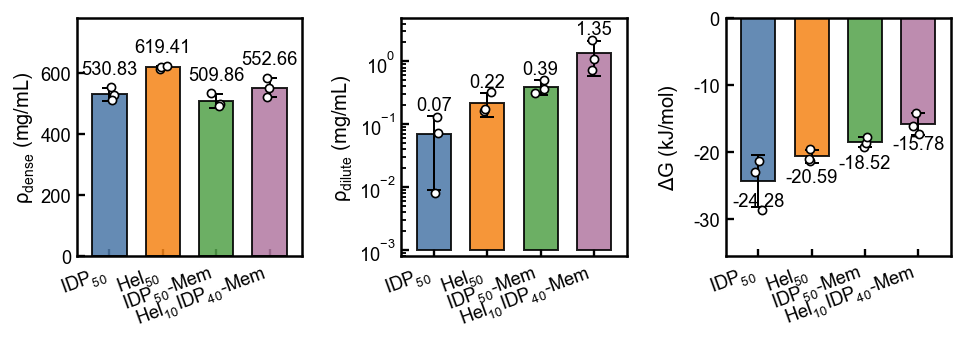

已保存组合图: free_energy_dense_dilute_summary.png
已保存组合图: free_energy_dense_dilute_summary.pdf


In [49]:
from pathlib import Path
import csv
import numpy as np
import matplotlib.pyplot as plt

if "new_subplots" not in globals():
    raise RuntimeError("请先运行第一个统一绘图风格 cell，再运行这个组合 cell。")

def _read_csv_rows(path):
    path = Path(path)
    with path.open(newline="", encoding="utf-8") as handle:
        return list(csv.DictReader(handle))

def _load_free_energy_rows_from_csv(path=None):
    raw_dir = globals().get("RAW_DATA_DIR", DENSITY_OUTPUT_DIR / "plot_raw_data")
    path = Path(path) if path is not None else raw_dir / "free_energy_replicates.csv"
    numeric_keys = [
        "deltaG", "rho_dense", "rho_dilute", "deltaG_fit",
        "rho_dilute_fit", "Rc", "w", "valid_radius",
]
    rows = []
    for raw in _read_csv_rows(path):
        row = dict(raw)
        for key in numeric_keys:
            if key in row and row[key] not in (None, ""):
                try:
                    row[key] = float(row[key])
                except Exception:
                    row[key] = np.nan
        if "replicate" in row and row["replicate"] not in (None, ""):
            try:
                row["replicate"] = int(float(row["replicate"]))
            except Exception:
                row["replicate"] = 0
        if np.isfinite(row.get("rho_dilute_fit", np.nan)):
            row["rho_dilute"] = row["rho_dilute_fit"]
        if np.isfinite(row.get("deltaG_fit", np.nan)):
            row["deltaG"] = row["deltaG_fit"]
        rows.append(row)
    return rows

def _ensure_inputs():
    global free_energy_rows, systems_config
    raw_dir = globals().get("RAW_DATA_DIR", DENSITY_OUTPUT_DIR / "plot_raw_data")
    if "free_energy_rows" not in globals() or len(free_energy_rows) == 0:
        csv_path = raw_dir / "free_energy_replicates.csv"
        if not csv_path.exists():
            raise RuntimeError(f"未找到已有绘图数据: {csv_path}。请先运行前面的密度分析 cell。")
        free_energy_rows = _load_free_energy_rows_from_csv(csv_path)
        print(f"已从已有数据读取 free_energy_rows: {csv_path}")
    if "systems_config" not in globals() or len(systems_config) == 0:
        group_titles = []
        for row in free_energy_rows:
            group = row.get("group")
            if group and group not in group_titles:
                group_titles.append(group)
        systems_config = [{"title": group} for group in group_titles]
        print("已根据已有数据恢复 group 顺序。")

def _group_values(key, positive_only=False):
    values_by_group = []
    for group in group_order:
        values = np.array([
            row.get(key, np.nan)
            for row in free_energy_rows
            if row.get("group") == group and np.isfinite(row.get(key, np.nan))
        ], dtype=float)
        if positive_only:
            values = values[values > 0]
        values_by_group.append(values)
    return values_by_group

def _summarize(values_by_group):
    means = np.array([np.nanmean(values) if values.size else np.nan for values in values_by_group], dtype=float)
    sds = np.array([np.nanstd(values, ddof=1) if values.size > 1 else 0.0 for values in values_by_group], dtype=float)
    counts = np.array([values.size for values in values_by_group], dtype=int)
    return means, sds, counts

def _format_value(value):
    if not np.isfinite(value):
        return "nan"
    if abs(value) >= 10:
        return f"{value:.1f}"
    if abs(value) >= 1:
        return f"{value:.2f}"
    return f"{value:.3g}"

def _draw_phase_panel(ax, values_by_group, ylabel, colors, log_scale=False, ylabel_pad=4):
    means, sds, counts = _summarize(values_by_group)
    x = np.arange(len(values_by_group))
    finite_arrays = [values for values in values_by_group if values.size]
    finite_values = np.concatenate(finite_arrays) if finite_arrays else np.array([], dtype=float)
    finite_values = finite_values[np.isfinite(finite_values)]
    if log_scale:
        finite_values = finite_values[finite_values > 0]
    if finite_values.size == 0:
        ax.text(0.5, 0.5, "No valid data", transform=ax.transAxes, ha="center", va="center")
        ax.set_axis_off()
        return means, sds, counts

    if log_scale:
        bar_bottom = 10 ** np.floor(np.log10(np.nanmin(finite_values) * 0.5))
        heights = np.maximum(means - bar_bottom, bar_bottom * 0.05)
        lower_err = np.minimum(sds, np.maximum(means - bar_bottom * 1.05, 0))
        yerr = np.vstack([lower_err, sds])
        ax.bar(
            x, heights, bottom=bar_bottom, yerr=yerr, width=0.64, color=colors,
            edgecolor="black", linewidth=1.2, alpha=0.86, capsize=4,
            error_kw=dict(ecolor="black", lw=1.2, capthick=1.2), zorder=2,
        )
        ax.set_yscale("log")
        upper = max(np.nanmax(finite_values), np.nanmax(means + sds))
        ax.set_ylim(bar_bottom * 0.8, upper * 2.2)
    else:
        ax.bar(
            x, means, yerr=sds, width=0.64, color=colors,
            edgecolor="black", linewidth=1.2, alpha=0.86, capsize=4,
            error_kw=dict(ecolor="black", lw=1.2, capthick=1.2), zorder=2,
        )
        upper = max(np.nanmax(finite_values), np.nanmax(means + sds))
        ax.set_ylim(0, upper * 1.25)

    rng = np.random.default_rng(7)
    for i, values in enumerate(values_by_group):
        if values.size == 0:
            continue
        jitter = rng.uniform(-0.10, 0.10, size=values.size)
        ax.scatter(
            np.full(values.size, x[i]) + jitter,
            values,
            s=24,
            facecolor="white",
            edgecolor="black",
            linewidth=1.0,
            zorder=4,
        )

    for i, (mean_value, sd_value) in enumerate(zip(means, sds)):
        if not np.isfinite(mean_value):
            continue
        if log_scale:
            label_y = max(mean_value + sd_value, mean_value) * 1.1
        else:
            label_y = mean_value + sd_value + ax.get_ylim()[1] * 0.04
        ax.text(
            x[i], label_y, f"{mean_value:.2f}", ha="center", va="bottom",
            fontsize=globals().get("TEXT_FONTSIZE", float(plt.rcParams["font.size"])),
            fontweight="bold", zorder=5,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(bar_labels, rotation=20, ha="right")
    ax.set_ylabel(ylabel, labelpad=ylabel_pad)
    ax.margins(x=0.08)
    return means, sds, counts

def _draw_free_energy_panel(ax, values_by_group, ylabel, colors, ylabel_pad=4, xtick_pad=10):
    means, sds, counts = _summarize(values_by_group)
    x = np.arange(len(values_by_group))
    finite_arrays = [values for values in values_by_group if values.size]
    finite_values = np.concatenate(finite_arrays) if finite_arrays else np.array([], dtype=float)
    finite_values = finite_values[np.isfinite(finite_values)]
    if finite_values.size == 0:
        ax.text(0.5, 0.5, "No valid data", transform=ax.transAxes, ha="center", va="center")
        ax.set_axis_off()
        return means, sds, counts

    lower = np.nanmin(finite_values)
    upper = 0.0
    margin = max(abs(lower) * 0.12, 0.5)
    label_space = max(abs(lower) * 0.12, 1.0)
    ax.bar(
        x, means, yerr=sds, width=0.64, color=colors,
        edgecolor="black", linewidth=1.2, alpha=0.86, capsize=4,
        error_kw=dict(ecolor="black", lw=1.2, capthick=1.2), zorder=2,
    )
    ax.axhline(0, color="black", lw=1.0, alpha=0.7, zorder=1)
    ax.set_ylim(lower - margin - label_space, upper)

    rng = np.random.default_rng(17)
    for i, values in enumerate(values_by_group):
        if values.size == 0:
            continue
        jitter = rng.uniform(-0.10, 0.10, size=values.size)
        ax.scatter(
            np.full(values.size, x[i]) + jitter,
            values,
            s=24,
            facecolor="white",
            edgecolor="black",
            linewidth=1.0,
            zorder=4,
        )

    label_offset = abs(lower) * 0.04
    for i, (mean_value, sd_value) in enumerate(zip(means, sds)):
        if not np.isfinite(mean_value):
            continue
        label_y = mean_value - (label_offset * 1.5)
        ax.text(
            x[i], label_y, f"{mean_value:.2f}", ha="center", va="top",
            fontsize=globals().get("TEXT_FONTSIZE", float(plt.rcParams["font.size"])),
            fontweight="bold", zorder=5,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(bar_labels, rotation=20, ha="right")
    ax.set_ylabel(ylabel, labelpad=ylabel_pad)
    ax.tick_params(axis="x", pad=xtick_pad)
    ax.margins(x=0.08)
    return means, sds, counts

_ensure_inputs()

group_order = [cfg["title"] for cfg in systems_config]
bar_labels = [
    r"$\mathrm{IDP}_{50}$",
    r"$\mathrm{Hel}_{50}$",
    r"$\mathrm{IDP}_{50}$-Mem",
    r"$\mathrm{Hel}_{10}\mathrm{IDP}_{40}$-Mem",
    ]
bar_colors = ["#4C78A8", "#F58518", "#54A24B", "#B279A2"]

dense_values = _group_values("rho_dense", positive_only=True)
dilute_values = _group_values("rho_dilute", positive_only=True)
free_energy_values = _group_values("deltaG")

fig, axes = new_subplots(1, 3, preset="double_short")
fig.subplots_adjust(wspace=0.44, left=0.07, right=0.995, top=0.98, bottom=0.26)

_draw_phase_panel(axes[0], dense_values, r"$\rho_{dense}$ (mg/mL)", bar_colors, log_scale=False, ylabel_pad=2)
_draw_phase_panel(axes[1], dilute_values, r"$\rho_{dilute}$ (mg/mL)", bar_colors, log_scale=True, ylabel_pad=2)
_draw_free_energy_panel(axes[2], free_energy_values, r"$\Delta G_{\mathrm{app}}$ (kJ/mol)", bar_colors, ylabel_pad=8, xtick_pad=3)

for ax in axes:
    ax.set_title("")

combined_path_png = DENSITY_OUTPUT_DIR / "free_energy_dense_dilute_summary.png"
combined_path_pdf = DENSITY_OUTPUT_DIR / "free_energy_dense_dilute_summary.pdf"
fig.savefig(combined_path_png, dpi=600, bbox_inches="tight", pad_inches=0.02)
fig.savefig(combined_path_pdf, bbox_inches="tight", pad_inches=0.02)
plt.show()

print(f"已保存组合图: {combined_path_png}")
print(f"已保存组合图: {combined_path_pdf}")